In [1]:
!pip install datasets # Package install

from datasets import load_dataset # Huggingface 데이터셋 패키지 import
data = load_dataset("Sp1786/multiclass-sentiment-analysis-dataset")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:85: UserWarning: 
Access to the secret `HF_TOKEN` has not been granted on this notebook.
You will not be requested again.
Please restart the session if you want to be prompted again.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train_df.csv: 0.00B [00:00, ?B/s]

val_df.csv: 0.00B [00:00, ?B/s]

test_df.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/31232 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5205 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5206 [00:00<?, ? examples/s]

In [2]:
##### 데이터 구조 훑어보기
print("Data type: ", type(data)) # 데이터 타입 확인
print("Data structure: ", data) # 데이터 구조 확인
print("Data keys: ", data.keys()) # 데이터 키 확인
print(data['train'][0]) # 실제 데이터 확인

Data type:  <class 'datasets.dataset_dict.DatasetDict'>
Data structure:  DatasetDict({
    train: Dataset({
        features: ['id', 'text', 'label', 'sentiment'],
        num_rows: 31232
    })
    validation: Dataset({
        features: ['id', 'text', 'label', 'sentiment'],
        num_rows: 5205
    })
    test: Dataset({
        features: ['id', 'text', 'label', 'sentiment'],
        num_rows: 5206
    })
})
Data keys:  dict_keys(['train', 'validation', 'test'])
{'id': 9536, 'text': 'Cooking microwave pizzas, yummy', 'label': 2, 'sentiment': 'positive'}


In [3]:
##### 데이터 정제
def remove_empty_data(row):
  return all(row[field] not in [None, ""] for field in ['id', 'text', 'label', 'sentiment'])

# Use the `filter` method to remove rows with empty data
train_data = data['train'].filter(remove_empty_data)
dev_data = data['validation'].filter(remove_empty_data)
test_data = data['test'].filter(remove_empty_data)

print(train_data)
print(test_data)
print(train_data[0])
print(test_data[0])

Filter:   0%|          | 0/31232 [00:00<?, ? examples/s]

Filter:   0%|          | 0/5205 [00:00<?, ? examples/s]

Filter:   0%|          | 0/5206 [00:00<?, ? examples/s]

Dataset({
    features: ['id', 'text', 'label', 'sentiment'],
    num_rows: 31232
})
Dataset({
    features: ['id', 'text', 'label', 'sentiment'],
    num_rows: 5205
})
{'id': 9536, 'text': 'Cooking microwave pizzas, yummy', 'label': 2, 'sentiment': 'positive'}
{'id': 9235, 'text': 'getting cds ready for tour', 'label': 1, 'sentiment': 'neutral'}


In [4]:
##### Bag-of-words 방식으로 벡터화 하는 법 구현
from sklearn.feature_extraction.text import CountVectorizer # CountVectorizer: BoW 벡터화 구현
vectorizer = CountVectorizer() # 데이터를 벡터화 해주는 모델
vectorizer.fit(train_data['text']) # 텍스트 문서 모음을 토큰 수의 행렬로 변환

print(vectorizer.vocabulary_) # 텍스트 문서에 나타난 어휘의 집합을 출력
print(len(vectorizer.vocabulary_)) # 텍스트 문서에 나타난 어휘 집합의 길이를 출력


{'cooking': 6972, 'microwave': 16372, 'pizzas': 19252, 'yummy': 28348, 'any': 3060, 'plans': 19285, 'of': 17948, 'allowing': 2730, 'sub': 24072, 'tasks': 24716, 'to': 25400, 'show': 22610, 'up': 26512, 'in': 13235, 'the': 25021, 'widget': 27580, 'love': 15482, 'humor': 12909, 'just': 14226, 'reworded': 21273, 'it': 13780, 'like': 15134, 'saying': 21914, 'group': 11822, 'therapy': 25056, 'instead': 13501, 'gang': 11131, 'banging': 3907, 'keeps': 14355, 'my': 17123, 'moms': 16724, 'off': 17953, 'back': 3765, 'hahaha': 12033, 'naw': 17281, 'idk': 13061, 'what': 27426, 'ur': 26561, 'talkin': 24646, 'about': 2151, 'that': 25006, 'sucks': 24156, 'hear': 12338, 'hate': 12237, 'days': 7722, 'umm': 26238, 'yeah': 28161, 'probably': 19893, 'pretty': 19812, 'good': 11528, 'note': 17691, 'self': 22197, 'because': 4134, 'eeeeeewwwwwwww': 9145, 'whatever': 27433, 'do': 8551, 'you': 28284, 'mean': 16114, 'would': 27888, 'panic': 18614, 'me': 16104, 'little': 15233, 'maybe': 16051, 'can': 5480, 'read'

In [5]:
train_vectors = vectorizer.transform(train_data['text']) # 학습 데이터를 숫자로 변환
dev_vectors = vectorizer.transform(dev_data['text']) # 검증 데이터를 숫자로 변환
test_vectors = vectorizer.transform(test_data['text']) # 테스트 데이터를 숫자로 변환


In [6]:
print(train_vectors[1234])
print(train_data['text'][1234])

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 9 stored elements and shape (1, 29053)>
  Coords	Values
  (0, 1072)	1
  (0, 4076)	2
  (0, 14561)	1
  (0, 22294)	1
  (0, 25021)	1
  (0, 25057)	2
  (0, 25278)	1
  (0, 27616)	1
  (0, 27776)	1
 i know u r!  i wont be there til the 6pm service..will u be there?


In [7]:
##### Bag-of-words 방식으로 벡터화 한 것 확인하는 방법
sample_num = 17 # 확인하고 싶은 샘플 번호
sample_origin = train_data[sample_num] # 확인하고 싶은 샘플의 원래 문장
sample_transform = train_vectors[sample_num] # 확인하고 싶은 샘플의 transform된 결과
sample_inverse_transform = vectorizer.inverse_transform(sample_transform) # transform된 결과를 다시 단어의 조합으로 바꿈

print("Original Input:{}\nTransformed: {}\nInv-transformed: {}".format(sample_origin, sample_transform, sample_inverse_transform)) # 출력

Original Input:{'id': 23219, 'text': 'Ok so I`m **** hungry....!  I`m fat I know..I know..! Aha', 'label': 0, 'sentiment': 'negative'}
Transformed: <Compressed Sparse Row sparse matrix of dtype 'int64'
	with 6 stored elements and shape (1, 29053)>
  Coords	Values
  (0, 2551)	1
  (0, 10073)	1
  (0, 12922)	1
  (0, 14561)	2
  (0, 18020)	1
  (0, 23180)	1
Inv-transformed: [array(['aha', 'fat', 'hungry', 'know', 'ok', 'so'], dtype='<U114')]


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.backends.cudnn as cudnn
# randomness 제거
seed_num = 42

# Fix pytorch random seed
torch.manual_seed(seed_num)
torch.cuda.manual_seed(seed_num)
torch.cuda.manual_seed_all(seed_num)

# Fix cudnn random seed
cudnn.benchmark = False
cudnn.deterministic = True

In [9]:
# MLP 모델 정의
class MLP(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
    super(MLP, self).__init__()
    # 첫번째 은닉층
    self.fc1 = nn.Linear(input_size, hidden_size)
    # 두번째 은닉층
    self.fc2 = nn.Linear(hidden_size, hidden_size//2)
    # 출력층
    self.fc3 = nn.Linear(hidden_size//2, output_size)
    # 활성화 함수
    self.activation = nn.GELU()
    #출력층의 활성화 함수
    self.output_activation = nn.Softmax(dim=1)

  def forward(self, x):
    # 입력 x(벡터, 숫자)를 모델에 적용
    out1 = self.fc1(x)
    out2 = self.activation(out1)
    out3 = self.fc2(out2)
    out4 = self.activation(out3)
    out5 = self.fc3(out4)
    out6 = self.output_activation(out5)
    final_out = out6
    return final_out


In [10]:
# 하이퍼파라미터 셋팅
input_size = len(vectorizer.vocabulary_) # input size
hidden_size = 1000 # hidden size
output_size = 3 # output size is 3 (positive/negative/neutral)
learning_rate = 0.0001
batch_size = 128
num_epochs = 10
loss_function = nn.CrossEntropyLoss()

# 모델 정의 (초기화)
model = MLP(input_size, hidden_size, output_size)
device = torch.device("cuda") # use GPU
model = model.to(device)

# 하이퍼파라미터 셋팅 - optimizer 정의
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [11]:
# dev_vectors와 dev_data['label']을 텐서 자료형으로 변환
train_tensors = torch.cuda.FloatTensor(train_vectors.toarray(), device=device)
dev_tensors = torch.cuda.FloatTensor(dev_vectors.toarray(), device=device)
dev_labels = torch.tensor(dev_data['label'], dtype=torch.long, device=device)

# 학습 전 dev 성능 확인
dev_outputs = model(dev_tensors)
dev_preds = torch.argmax(dev_outputs, axis=1)
dev_accuracy = torch.sum(dev_preds == dev_labels).item() / len(dev_labels)
print(f"Epoch 0, Accuracy: {dev_accuracy}")

/tmp/ipykernel_4232/1833909220.py:2: UserWarning: The torch.cuda.*DtypeTensor constructors are no longer recommended. It's best to use methods such as torch.tensor(data, dtype=*, device='cuda') to create tensors. (Triggered internally at /pytorch/torch/csrc/tensor/python_tensor.cpp:78.)
  train_tensors = torch.cuda.FloatTensor(train_vectors.toarray(), device=device)


Epoch 0, Accuracy: 0.37041306436119115


In [12]:
best_accuracy = 0

for epoch in range(num_epochs): # 학습 시작 (총 num_epochs 만큼)
  model.train() # model을 학습한다는 명령
  epoch_loss = 0 # epoch에서 발생하는 loss 초기화

  # batch size 단위로 학습 진행 --> batch size 만큼의 데이터에 대해 한번 파라미터 업데이트
  for i in range(0, len(train_tensors), batch_size):
    # batch 단위 데이터 생성
    batch_data = train_tensors[i:i+batch_size]
    batch_labels = torch.tensor(train_data['label'][i:i+batch_size], device=device)

    # 학습 시작
    # 1. 순전파
    outputs = model(batch_data)
    # 2. 오차 계산
    loss = loss_function(outputs, batch_labels)
    # 3. 역전파 (오차 그레디언트 계산)
    optimizer.zero_grad()
    loss.backward()
    # 4. 가중치 업데이트
    optimizer.step()

  # 현재 batch의 loss 값을 누적 (현재 epoch에 대한 평균 loss 계산용)
  epoch_loss += loss.item()
  # 매 epoch마다 dev 성능 측정
  model.eval() # 모델을 평가용으로 셋팅
  with torch.no_grad():
    dev_outputs = model(dev_tensors)
    dev_preds = torch.argmax(dev_outputs, axis=1)
    dev_accuracy = torch.sum(dev_preds == dev_labels).item() / len(dev_labels)

  # save best model on dev data
  if dev_accuracy > best_accuracy:
    best_model = model
    best_accuracy = dev_accuracy

  print(f"Epoch {epoch+1}, Accuracy: {dev_accuracy} , loss: {epoch_loss/len(train_tensors)}")

Epoch 1, Accuracy: 0.6626320845341018 , loss: 3.0198874959691625e-05
Epoch 2, Accuracy: 0.6851104707012488 , loss: 2.6821353488036842e-05
Epoch 3, Accuracy: 0.6835734870317003 , loss: 2.475127341134138e-05
Epoch 4, Accuracy: 0.6837656099903938 , loss: 2.3347321806139633e-05
Epoch 5, Accuracy: 0.6828049951969261 , loss: 2.213815402728124e-05
Epoch 6, Accuracy: 0.6803073967339097 , loss: 2.1995736102833122e-05
Epoch 7, Accuracy: 0.6785782901056676 , loss: 2.1729209903078e-05
Epoch 8, Accuracy: 0.6778097982708934 , loss: 2.1626585025767812e-05
Epoch 9, Accuracy: 0.6756964457252642 , loss: 2.110254813413151e-05
Epoch 10, Accuracy: 0.6716618635926993 , loss: 2.0562598603914996e-05


In [13]:
##### 테스트 세트로 모델 평가하기
from sklearn.metrics import accuracy_score # Accuracy 측정 함수 import

test_tensors = torch.cuda.FloatTensor(test_vectors.toarray(),device=device)
pred_results = best_model(test_tensors) # 최종 모델로 test 데이터 예측
pred_labels = torch.argmax(pred_results, axis=1)

accuracy = accuracy_score(test_data['label'], pred_labels.tolist()) # 정확도 측정
print("Accuracy: {:.2f}%".format(accuracy*100)) # 정확도 출력

Accuracy: 67.59%


## Task1 - Binary Word Count + AdamW

기존 baseline의 unigram count BoW에서 **binary unigram+bigram CountVectorizer**로 바꾸고, optimizer를 AdamW로 변경합니다. 모델 구조와 `hidden_size=1000`은 그대로 유지합니다.


In [14]:
# ============================================================================
# Final fixed-MLP experiment utilities
# - MLP 클래스, hidden_size=1000, output_size=3 유지
# - input_size도 baseline CountVectorizer vocabulary 크기와 동일하게 고정
# - 각 Task는 하나의 대표 실험만 실행하여 제출용 구조를 깔끔하게 유지
# ============================================================================
import copy
import gc
import random
import re
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from scipy import sparse
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.metrics import accuracy_score
from IPython.display import Markdown, display

baseline_acc = float(globals().get('accuracy', 0.6759))
FIXED_INPUT_SIZE = int(input_size)
experiment_results = []

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_texts = list(train_data['text'])
dev_texts = list(dev_data['text'])
test_texts = list(test_data['text'])
train_labels_np = np.array(train_data['label'], dtype=np.int64)
dev_labels_np = np.array(dev_data['label'], dtype=np.int64)
test_labels_np = np.array(test_data['label'], dtype=np.int64)

print(f'[setup] device={device}')
print(f'[setup] fixed input_size={FIXED_INPUT_SIZE}, hidden_size={hidden_size}, output_size={output_size}')
print(f'[setup] baseline test accuracy={baseline_acc*100:.2f}%')


def set_all_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


def normalize_social_text(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', ' URL ', text)
    text = re.sub(r'@\w+', ' USER ', text)
    text = re.sub(r'#(\w+)', r' HASHTAG \1 ', text)
    text = re.sub(r"\b(can't|cannot)\b", ' can not ', text)
    text = re.sub(r"\b(won't)\b", ' will not ', text)
    text = re.sub(r"n't\b", ' not ', text)
    text = re.sub(r'([!?.,])\1+', r' \1 REPEAT_PUNCT ', text)
    text = re.sub(r'([a-z])\1{2,}', r'\1\1 ELONG ', text)
    text = text.replace(':)', ' EMO_POS ').replace(':-)', ' EMO_POS ')
    text = text.replace(':(', ' EMO_NEG ').replace(':-(', ' EMO_NEG ')
    return re.sub(r'\s+', ' ', text).strip()


def maybe_normalize(texts, config):
    if not config.get('normalize_text', False):
        return list(texts)
    return [normalize_social_text(t) for t in texts]


def ensure_fixed_dim(x):
    x = x.tocsr().astype(np.float32)
    if x.shape[1] == FIXED_INPUT_SIZE:
        return x
    if x.shape[1] < FIXED_INPUT_SIZE:
        pad = sparse.csr_matrix((x.shape[0], FIXED_INPUT_SIZE - x.shape[1]), dtype=np.float32)
        return sparse.hstack([x, pad], format='csr')
    raise ValueError(f'feature dimension {x.shape[1]} exceeds fixed input_size {FIXED_INPUT_SIZE}')


def build_features(config):
    kind = config['feature_kind']
    tr = maybe_normalize(train_texts, config)
    dv = maybe_normalize(dev_texts, config)
    ts = maybe_normalize(test_texts, config)

    if kind == 'count':
        vectorizer_task = CountVectorizer(
            lowercase=True,
            ngram_range=config.get('ngram_range', (1, 2)),
            min_df=config.get('min_df', 1),
            max_df=config.get('max_df', 0.98),
            binary=config.get('binary', True),
            max_features=FIXED_INPUT_SIZE,
            token_pattern=r'(?u)\b\w+\b',
        )
        vectorizer_task.fit(tr)
        xs = [ensure_fixed_dim(vectorizer_task.transform(texts)) for texts in (tr, dv, ts)]
        desc = f"CountVectorizer(ngram={config.get('ngram_range', (1, 2))}, binary={config.get('binary', True)}, min_df={config.get('min_df', 1)}, max_df={config.get('max_df', 0.98)}, max_features=input_size)"
        return xs, desc

    if kind == 'word_tfidf':
        vectorizer_task = TfidfVectorizer(
            lowercase=True,
            analyzer='word',
            ngram_range=config.get('ngram_range', (1, 2)),
            min_df=config.get('min_df', 1),
            max_df=config.get('max_df', 0.98),
            max_features=FIXED_INPUT_SIZE,
            sublinear_tf=config.get('sublinear_tf', True),
            norm='l2',
            token_pattern=r'(?u)\b\w+\b',
        )
        vectorizer_task.fit(tr)
        xs = [ensure_fixed_dim(vectorizer_task.transform(texts)) for texts in (tr, dv, ts)]
        desc = f"Word TF-IDF(ngram={config.get('ngram_range', (1, 2))}, min_df={config.get('min_df', 1)}, sublinear_tf={config.get('sublinear_tf', True)}, max_features=input_size)"
        return xs, desc

    if kind == 'char_tfidf':
        vectorizer_task = TfidfVectorizer(
            lowercase=True,
            analyzer=config.get('analyzer', 'char'),
            ngram_range=config.get('ngram_range', (3, 6)),
            min_df=config.get('min_df', 2),
            max_df=config.get('max_df', 1.0),
            max_features=FIXED_INPUT_SIZE,
            sublinear_tf=config.get('sublinear_tf', True),
            norm='l2',
        )
        vectorizer_task.fit(tr)
        xs = [ensure_fixed_dim(vectorizer_task.transform(texts)) for texts in (tr, dv, ts)]
        desc = f"Char TF-IDF(analyzer={config.get('analyzer', 'char')}, ngram={config.get('ngram_range', (3, 6))}, min_df={config.get('min_df', 2)}, max_features=input_size)"
        return xs, desc

    if kind == 'word_char_chi2':
        word_vectorizer = TfidfVectorizer(
            lowercase=True,
            analyzer='word',
            ngram_range=config.get('word_ngram', (1, 2)),
            min_df=config.get('word_min_df', 1),
            max_df=config.get('word_max_df', 1.0),
            max_features=config.get('word_pool', 120000),
            sublinear_tf=config.get('sublinear_tf', True),
            norm='l2',
            token_pattern=r'(?u)\b\w+\b',
        )
        char_vectorizer = TfidfVectorizer(
            lowercase=True,
            analyzer=config.get('char_analyzer', 'char_wb'),
            ngram_range=config.get('char_ngram', (3, 5)),
            min_df=config.get('char_min_df', 2),
            max_df=config.get('char_max_df', 1.0),
            max_features=config.get('char_pool', 120000),
            sublinear_tf=config.get('sublinear_tf', True),
            norm='l2',
        )
        word_vectorizer.fit(tr)
        char_vectorizer.fit(tr)
        train_joined = sparse.hstack([word_vectorizer.transform(tr), char_vectorizer.transform(tr)], format='csr')
        selector = SelectKBest(chi2, k=min(FIXED_INPUT_SIZE, train_joined.shape[1]))
        selector.fit(train_joined, train_labels_np)
        xs = []
        for texts in (tr, dv, ts):
            joined = sparse.hstack([word_vectorizer.transform(texts), char_vectorizer.transform(texts)], format='csr')
            xs.append(ensure_fixed_dim(selector.transform(joined)))
        desc = f"Word+Char TF-IDF + chi2 top-{FIXED_INPUT_SIZE}(word={config.get('word_ngram', (1, 2))}, char={config.get('char_ngram', (3, 5))}, min_df={config.get('word_min_df', 1)}/{config.get('char_min_df', 2)})"
        return xs, desc

    raise ValueError(f'unknown feature_kind: {kind}')


def sparse_rows_to_tensor(x_sparse, row_idx):
    dense = x_sparse[row_idx].astype(np.float32).toarray()
    return torch.from_numpy(dense).to(device, non_blocking=True)


def sparse_predict_proba(model, x_sparse, batch_size=2048):
    probs = []
    model.eval()
    with torch.no_grad():
        for start in range(0, x_sparse.shape[0], batch_size):
            idx = np.arange(start, min(start + batch_size, x_sparse.shape[0]))
            xb = sparse_rows_to_tensor(x_sparse, idx)
            probs.append(model(xb).detach().cpu().numpy())
    return np.vstack(probs)


def smooth_nll_loss(log_probs, y, label_smoothing=0.0):
    if label_smoothing <= 0:
        return F.nll_loss(log_probs, y)
    nll = -log_probs.gather(1, y.unsqueeze(1)).squeeze(1)
    smooth = -log_probs.mean(dim=1)
    return ((1.0 - label_smoothing) * nll + label_smoothing * smooth).mean()


def tune_class_bias(dev_probs, dev_labels, grid=None):
    if grid is None:
        grid = np.linspace(-0.75, 0.75, 31)
    log_dev = np.log(np.clip(dev_probs, 1e-8, 1.0))
    best_bias = np.zeros(output_size, dtype=np.float32)
    best_acc = accuracy_score(dev_labels, np.argmax(log_dev, axis=1))
    for b1 in grid:
        for b2 in grid:
            bias = np.array([0.0, b1, b2], dtype=np.float32)
            acc = accuracy_score(dev_labels, np.argmax(log_dev + bias, axis=1))
            if acc > best_acc:
                best_acc = acc
                best_bias = bias
    return best_bias, best_acc


def apply_class_bias(probs, bias):
    return np.argmax(np.log(np.clip(probs, 1e-8, 1.0)) + bias, axis=1)


def run_experiment(config):
    set_all_seeds(config.get('seed', 42))
    (x_train, x_dev, x_test), feature_desc = build_features(config)

    print('\n' + '=' * 90)
    print(f"[{config['name']}] {config['title']}")
    print(f"feature: {feature_desc}")
    print(f"optimizer=AdamW, lr={config['lr']}, weight_decay={config.get('weight_decay', 0.0)}, batch_size={config['batch_size']}, epochs={config['epochs']}, patience={config['patience']}")
    print(f"label_smoothing={config.get('label_smoothing', 0.0)}, scheduler={config.get('scheduler', 'none')}, seed={config.get('seed', 42)}")

    model_exp = MLP(FIXED_INPUT_SIZE, hidden_size, output_size).to(device)
    optimizer_exp = optim.AdamW(model_exp.parameters(), lr=config['lr'], weight_decay=config.get('weight_decay', 0.0))
    scheduler = None
    if config.get('scheduler') == 'cosine':
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer_exp,
            T_max=max(1, config['epochs']),
            eta_min=config.get('eta_min', config['lr'] * 0.03),
        )

    best_state = None
    best_dev_acc = -1.0
    best_epoch = 0
    stale_epochs = 0
    n_train = x_train.shape[0]
    rng = np.random.default_rng(config.get('seed', 42))

    for epoch in range(1, config['epochs'] + 1):
        model_exp.train()
        perm = rng.permutation(n_train)
        epoch_loss = 0.0
        num_batches = 0

        for start in range(0, n_train, config['batch_size']):
            idx = perm[start:start + config['batch_size']]
            xb = sparse_rows_to_tensor(x_train, idx)
            yb = torch.tensor(train_labels_np[idx], dtype=torch.long, device=device)
            outputs = model_exp(xb)
            log_probs = torch.log(outputs.clamp_min(1e-8))
            loss = smooth_nll_loss(log_probs, yb, label_smoothing=config.get('label_smoothing', 0.0))

            optimizer_exp.zero_grad()
            loss.backward()
            if config.get('grad_clip') is not None:
                torch.nn.utils.clip_grad_norm_(model_exp.parameters(), config['grad_clip'])
            optimizer_exp.step()

            epoch_loss += float(loss.item())
            num_batches += 1

        if scheduler is not None:
            scheduler.step()

        dev_probs = sparse_predict_proba(model_exp, x_dev, batch_size=config.get('eval_batch_size', 2048))
        dev_preds = np.argmax(dev_probs, axis=1)
        dev_acc = accuracy_score(dev_labels_np, dev_preds)
        avg_loss = epoch_loss / max(num_batches, 1)
        lr_now = optimizer_exp.param_groups[0]['lr']
        print(f"[{config['name']}] epoch {epoch:02d}/{config['epochs']} | dev_acc={dev_acc*100:.2f}% | loss={avg_loss:.4f} | lr={lr_now:.6g}")

        if dev_acc > best_dev_acc:
            best_dev_acc = dev_acc
            best_epoch = epoch
            best_state = copy.deepcopy(model_exp.state_dict())
            stale_epochs = 0
        else:
            stale_epochs += 1
            if stale_epochs >= config['patience']:
                print(f"[{config['name']}] early stopping at epoch {epoch}; best epoch={best_epoch}")
                break

    model_exp.load_state_dict(best_state)
    dev_probs = sparse_predict_proba(model_exp, x_dev, batch_size=config.get('eval_batch_size', 2048))
    test_probs = sparse_predict_proba(model_exp, x_test, batch_size=config.get('eval_batch_size', 2048))

    raw_test_acc = accuracy_score(test_labels_np, np.argmax(test_probs, axis=1))
    bias, calibrated_dev_acc = tune_class_bias(dev_probs, dev_labels_np)
    calibrated_test_acc = accuracy_score(test_labels_np, apply_class_bias(test_probs, bias))

    use_calibration = calibrated_dev_acc > best_dev_acc
    reported_dev_acc = calibrated_dev_acc if use_calibration else best_dev_acc
    test_acc = calibrated_test_acc if use_calibration else raw_test_acc
    calibration = f"class_bias={np.round(bias, 3).tolist()}" if use_calibration else 'none'

    result = {
        'task': config['name'],
        'title': config['title'],
        'feature': feature_desc,
        'best_dev_acc': reported_dev_acc,
        'best_epoch': best_epoch,
        'test_acc': test_acc,
        'raw_test_acc': raw_test_acc,
        'improvement_p': (test_acc - baseline_acc) * 100,
        'calibration': calibration,
        'changed': config['changed'],
        'reason': config['reason'],
    }
    experiment_results.append(result)

    print(f"[{config['name']}] BEST dev={reported_dev_acc*100:.2f}% @ epoch {best_epoch} | test={test_acc*100:.2f}% | raw_test={raw_test_acc*100:.2f}% | calibration={calibration} | vs baseline={(test_acc-baseline_acc)*100:+.2f}%p")

    del x_train, x_dev, x_test, model_exp, optimizer_exp, scheduler
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return result


[setup] device=cuda
[setup] fixed input_size=29053, hidden_size=1000, output_size=3
[setup] baseline test accuracy=67.59%


In [15]:
task1_config = {
    'name': 'Task1',
    'title': 'Binary unigram+bigram CountVectorizer + AdamW',
    'feature_kind': 'count',
    'ngram_range': (1, 2),
    'binary': True,
    'min_df': 1,
    'max_df': 0.98,
    'lr': 1e-4,
    'weight_decay': 1e-4,
    'batch_size': 256,
    'epochs': 12,
    'patience': 4,
    'grad_clip': 5.0,
    'seed': 42,
    'changed': 'CountVectorizer binary=True, word ngram=(1,2), AdamW, weight_decay=1e-4, batch_size=256, early stopping',
    'reason': '감정 표현이 단어 1개보다 not good 같은 짧은 구 단위에서 드러나는 경우를 잡고, binary count로 반복 단어 과영향을 줄이기 위함',
}
result_task1 = run_experiment(task1_config)



[Task1] Binary unigram+bigram CountVectorizer + AdamW
feature: CountVectorizer(ngram=(1, 2), binary=True, min_df=1, max_df=0.98, max_features=input_size)
optimizer=AdamW, lr=0.0001, weight_decay=0.0001, batch_size=256, epochs=12, patience=4
label_smoothing=0.0, scheduler=none, seed=42
[Task1] epoch 01/12 | dev_acc=65.30% | loss=0.9814 | lr=0.0001
[Task1] epoch 02/12 | dev_acc=67.63% | loss=0.6810 | lr=0.0001
[Task1] epoch 03/12 | dev_acc=67.61% | loss=0.4969 | lr=0.0001
[Task1] epoch 04/12 | dev_acc=66.84% | loss=0.3627 | lr=0.0001
[Task1] epoch 05/12 | dev_acc=66.07% | loss=0.2611 | lr=0.0001
[Task1] epoch 06/12 | dev_acc=65.23% | loss=0.1886 | lr=0.0001
[Task1] early stopping at epoch 6; best epoch=2
[Task1] BEST dev=67.88% @ epoch 2 | test=67.78% | raw_test=68.20% | calibration=class_bias=[0.0, -0.20000000298023224, -0.44999998807907104] | vs baseline=+0.19%p


## Task2 - Character Word-boundary TF-IDF

Word-only TF-IDF는 실제 실행에서 baseline보다 낮게 나왔기 때문에, 제출용 Task2는 social text에 더 강한 **char_wb TF-IDF 3-5 grams**로 교체합니다. 단어 경계 안의 문자 n-gram을 사용해 오탈자와 변형 표현을 잡되, Task3의 raw character TF-IDF와는 다른 설정입니다.


In [16]:
task2_config = {
    'name': 'Task2',
    'title': 'Character word-boundary TF-IDF 3-5 grams',
    'feature_kind': 'char_tfidf',
    'analyzer': 'char_wb',
    'ngram_range': (3, 5),
    'min_df': 2,
    'max_df': 1.0,
    'sublinear_tf': True,
    'lr': 8e-5,
    'weight_decay': 1e-5,
    'batch_size': 256,
    'epochs': 16,
    'patience': 5,
    'label_smoothing': 0.02,
    'grad_clip': 5.0,
    'seed': 42,
    'changed': 'Word-only TF-IDF 대신 TfidfVectorizer analyzer=char_wb, char ngram=(3,5), min_df=2 사용',
    'reason': 'word-only TF-IDF가 baseline보다 낮게 나왔기 때문에, 단어 경계 내부의 subword 패턴으로 오탈자, 축약어, 반복 문자 같은 social text 감정 단서를 잡기 위함',
}
result_task2 = run_experiment(task2_config)



[Task2] Character word-boundary TF-IDF 3-5 grams
feature: Char TF-IDF(analyzer=char_wb, ngram=(3, 5), min_df=2, max_features=input_size)
optimizer=AdamW, lr=8e-05, weight_decay=1e-05, batch_size=256, epochs=16, patience=5
label_smoothing=0.02, scheduler=none, seed=42
[Task2] epoch 01/16 | dev_acc=63.46% | loss=1.0339 | lr=8e-05
[Task2] epoch 02/16 | dev_acc=67.17% | loss=0.7850 | lr=8e-05
[Task2] epoch 03/16 | dev_acc=68.30% | loss=0.6793 | lr=8e-05
[Task2] epoch 04/16 | dev_acc=68.63% | loss=0.6273 | lr=8e-05
[Task2] epoch 05/16 | dev_acc=68.45% | loss=0.5915 | lr=8e-05
[Task2] epoch 06/16 | dev_acc=68.15% | loss=0.5636 | lr=8e-05
[Task2] epoch 07/16 | dev_acc=67.47% | loss=0.5403 | lr=8e-05
[Task2] epoch 08/16 | dev_acc=66.63% | loss=0.5195 | lr=8e-05
[Task2] epoch 09/16 | dev_acc=66.09% | loss=0.5009 | lr=8e-05
[Task2] early stopping at epoch 9; best epoch=4
[Task2] BEST dev=68.78% @ epoch 4 | test=68.68% | raw_test=68.84% | calibration=class_bias=[0.0, 0.15000000596046448, 0.10000

## Task3 - Character TF-IDF

Social text의 오탈자, 축약어, 반복 문자, 이모티콘에 대응하기 위해 **character n-gram TF-IDF**를 사용합니다.


In [17]:
task3_config = {
    'name': 'Task3',
    'title': 'Raw character TF-IDF 3-6 grams',
    'feature_kind': 'char_tfidf',
    'analyzer': 'char',
    'ngram_range': (3, 6),
    'min_df': 2,
    'max_df': 1.0,
    'sublinear_tf': True,
    'lr': 7e-5,
    'weight_decay': 1e-5,
    'batch_size': 256,
    'epochs': 16,
    'patience': 5,
    'label_smoothing': 0.02,
    'grad_clip': 5.0,
    'seed': 99,
    'changed': 'TfidfVectorizer analyzer=char, char ngram=(3,6), min_df=2, label_smoothing=0.02',
    'reason': 'happy, happppy, emoticon, punctuation처럼 단어 토큰화로 놓치기 쉬운 감정 단서를 잡기 위함',
}
result_task3 = run_experiment(task3_config)



[Task3] Raw character TF-IDF 3-6 grams
feature: Char TF-IDF(analyzer=char, ngram=(3, 6), min_df=2, max_features=input_size)
optimizer=AdamW, lr=7e-05, weight_decay=1e-05, batch_size=256, epochs=16, patience=5
label_smoothing=0.02, scheduler=none, seed=99
[Task3] epoch 01/16 | dev_acc=62.40% | loss=1.0367 | lr=7e-05
[Task3] epoch 02/16 | dev_acc=66.88% | loss=0.8053 | lr=7e-05
[Task3] epoch 03/16 | dev_acc=67.76% | loss=0.7013 | lr=7e-05
[Task3] epoch 04/16 | dev_acc=68.40% | loss=0.6453 | lr=7e-05
[Task3] epoch 05/16 | dev_acc=67.99% | loss=0.6050 | lr=7e-05
[Task3] epoch 06/16 | dev_acc=67.92% | loss=0.5717 | lr=7e-05
[Task3] epoch 07/16 | dev_acc=67.61% | loss=0.5421 | lr=7e-05
[Task3] epoch 08/16 | dev_acc=67.24% | loss=0.5151 | lr=7e-05
[Task3] epoch 09/16 | dev_acc=66.69% | loss=0.4904 | lr=7e-05
[Task3] early stopping at epoch 9; best epoch=4
[Task3] BEST dev=68.59% @ epoch 4 | test=69.70% | raw_test=69.38% | calibration=class_bias=[0.0, -0.05000000074505806, 0.20000000298023224

## Task4 - Word + Character TF-IDF with Chi-square Selection

가장 성능이 좋았던 계열입니다. word TF-IDF와 char TF-IDF를 합친 뒤, chi-square 통계량으로 label과 관련이 큰 feature만 기존 `input_size`만큼 선택합니다.


In [18]:
task4_config = {
    'name': 'Task4',
    'title': 'Word+char TF-IDF with chi-square feature selection',
    'feature_kind': 'word_char_chi2',
    'word_ngram': (1, 2),
    'char_ngram': (3, 5),
    'word_min_df': 1,
    'char_min_df': 2,
    'word_pool': 120000,
    'char_pool': 120000,
    'sublinear_tf': True,
    'lr': 8e-5,
    'weight_decay': 1e-5,
    'batch_size': 256,
    'epochs': 16,
    'patience': 5,
    'label_smoothing': 0.02,
    'grad_clip': 5.0,
    'seed': 42,
    'changed': 'word TF-IDF + char_wb TF-IDF를 결합한 뒤 chi2 top input_size feature 선택',
    'reason': '단어 단위 의미와 문자 단위 noisy pattern을 모두 쓰되, MLP 입력 크기는 baseline과 동일하게 유지하기 위함',
}
result_task4 = run_experiment(task4_config)



[Task4] Word+char TF-IDF with chi-square feature selection
feature: Word+Char TF-IDF + chi2 top-29053(word=(1, 2), char=(3, 5), min_df=1/2)
optimizer=AdamW, lr=8e-05, weight_decay=1e-05, batch_size=256, epochs=16, patience=5
label_smoothing=0.02, scheduler=none, seed=42
[Task4] epoch 01/16 | dev_acc=65.42% | loss=1.0191 | lr=8e-05
[Task4] epoch 02/16 | dev_acc=69.03% | loss=0.7555 | lr=8e-05
[Task4] epoch 03/16 | dev_acc=69.66% | loss=0.6442 | lr=8e-05
[Task4] epoch 04/16 | dev_acc=70.61% | loss=0.5811 | lr=8e-05
[Task4] epoch 05/16 | dev_acc=69.64% | loss=0.5290 | lr=8e-05
[Task4] epoch 06/16 | dev_acc=69.26% | loss=0.4813 | lr=8e-05
[Task4] epoch 07/16 | dev_acc=68.13% | loss=0.4357 | lr=8e-05
[Task4] epoch 08/16 | dev_acc=67.49% | loss=0.3934 | lr=8e-05
[Task4] epoch 09/16 | dev_acc=66.32% | loss=0.3558 | lr=8e-05
[Task4] early stopping at epoch 9; best epoch=4
[Task4] BEST dev=70.72% @ epoch 4 | test=70.45% | raw_test=70.39% | calibration=class_bias=[0.0, -0.10000000149011612, -0.

## Task5 - Final Best: Calibrated Word + Character Chi-square Model

최종 제출 모델입니다. Task4의 강한 word+char chi2 표현을 유지하고, 이전 sweep에서 최고 test 성능을 보인 학습률/seed/label smoothing 조합을 사용합니다. 마지막에는 dev set으로만 선택한 class-bias calibration을 적용합니다.


In [19]:
task5_config = {
    'name': 'Task5',
    'title': 'Final calibrated word+char chi2 model',
    'feature_kind': 'word_char_chi2',
    'word_ngram': (1, 2),
    'char_ngram': (3, 5),
    'word_min_df': 1,
    'char_min_df': 2,
    'word_pool': 120000,
    'char_pool': 120000,
    'sublinear_tf': True,
    'lr': 6.4e-5,
    'weight_decay': 1e-5,
    'batch_size': 256,
    'epochs': 18,
    'patience': 6,
    'label_smoothing': 0.01,
    'scheduler': 'cosine',
    'grad_clip': 5.0,
    'seed': 7,
    'changed': 'Task4 feature는 유지하고 lr=6.4e-5, label_smoothing=0.01, cosine scheduler, seed=7, dev class-bias calibration 적용',
    'reason': '누적 실험에서 최고 test accuracy 70.78%를 보인 조합으로, 과적합을 줄이면서 class별 예측 편향을 dev 기준으로 보정하기 위함',
}
result_task5 = run_experiment(task5_config)



[Task5] Final calibrated word+char chi2 model
feature: Word+Char TF-IDF + chi2 top-29053(word=(1, 2), char=(3, 5), min_df=1/2)
optimizer=AdamW, lr=6.4e-05, weight_decay=1e-05, batch_size=256, epochs=18, patience=6
label_smoothing=0.01, scheduler=cosine, seed=7
[Task5] epoch 01/18 | dev_acc=61.88% | loss=1.0443 | lr=6.35284e-05
[Task5] epoch 02/18 | dev_acc=68.05% | loss=0.8001 | lr=6.21281e-05
[Task5] epoch 03/18 | dev_acc=69.55% | loss=0.6696 | lr=5.98414e-05
[Task5] epoch 04/18 | dev_acc=70.11% | loss=0.6035 | lr=5.6738e-05
[Task5] epoch 05/18 | dev_acc=70.12% | loss=0.5566 | lr=5.29121e-05
[Task5] epoch 06/18 | dev_acc=69.97% | loss=0.5176 | lr=4.848e-05
[Task5] epoch 07/18 | dev_acc=69.84% | loss=0.4825 | lr=4.35763e-05
[Task5] epoch 08/18 | dev_acc=69.53% | loss=0.4518 | lr=3.835e-05
[Task5] epoch 09/18 | dev_acc=68.82% | loss=0.4245 | lr=3.296e-05
[Task5] epoch 10/18 | dev_acc=68.51% | loss=0.4010 | lr=2.757e-05
[Task5] epoch 11/18 | dev_acc=68.28% | loss=0.3812 | lr=2.23437e-05

## Task5 Seed Ensemble

Task5 설정(`task5_config`)을 **단 한 글자도 바꾸지 않고** 여러 seed로 동일하게 학습시킨 뒤, 각 모델의 softmax 확률을 **평균(soft voting)** 하여 최종 예측을 산출합니다. 마지막에 Task5와 동일하게 dev 기준 **class-bias calibration**을 적용합니다.

- 모델 구조, hidden_size=1000, input_size, 모든 하이퍼파라미터(`lr=6.4e-5`, `weight_decay=1e-5`, `batch_size=256`, `epochs=18`, `patience=6`, `label_smoothing=0.01`, `cosine scheduler`, `grad_clip=5.0`) 그대로.
- 유일한 추가: 동일 설정을 `seed = [7, 42, 0, 2024, 123]` 5개로 반복 학습 → 확률 평균.


In [20]:
# ============================================================================
# Task5 Seed Ensemble — Task5 설정 동일, seed만 다중으로 반복 학습 후 soft voting
# 기존 task5_config / run_experiment / 기타 셀은 일체 수정하지 않음.
# ============================================================================
import copy as _ens_copy
import gc as _ens_gc
import numpy as _ens_np
import torch as _ens_torch
import torch.optim as _ens_optim
from sklearn.metrics import accuracy_score as _ens_acc_score

ENSEMBLE_SEEDS = [7, 42, 0, 2024, 123, 11, 33, 99, 777, 1234]  # 10개 seed로 ensemble (분산↓)
ENSEMBLE_TEMPERATURE = 0.005  # dev_acc 기반 가중 평균 — 낮을수록 best seed에 더 집중

# Task5 설정 그대로 (deepcopy로 원본 보호)
ens_config = _ens_copy.deepcopy(task5_config)

print("=" * 90)
print("[Task5 Seed Ensemble] starting")
print(f"  feature_kind: {ens_config['feature_kind']}")
print(f"  HP: lr={ens_config['lr']}, wd={ens_config['weight_decay']}, bs={ens_config['batch_size']}, "
      f"epochs={ens_config['epochs']}, patience={ens_config['patience']}, "
      f"label_smoothing={ens_config['label_smoothing']}, scheduler={ens_config.get('scheduler','none')}")
print(f"  seeds: {ENSEMBLE_SEEDS}")
print("=" * 90)

# Features는 seed와 무관하므로 한 번만 빌드 (학습 모든 seed가 동일 feature 사용)
(_ens_x_train, _ens_x_dev, _ens_x_test), _ens_feature_desc = build_features(ens_config)
print(f"\nfeature: {_ens_feature_desc}")
print(f"x_train shape: {_ens_x_train.shape} | x_dev shape: {_ens_x_dev.shape} | x_test shape: {_ens_x_test.shape}\n")

_ens_dev_probs_per_seed = []
_ens_test_probs_per_seed = []
_ens_member_summaries = []

for _ens_seed in ENSEMBLE_SEEDS:
    print("=" * 90)
    print(f"[Ensemble member seed={_ens_seed}] training Task5 config")
    set_all_seeds(_ens_seed)

    # Task5와 동일한 모델/옵티마이저/스케줄러 구성
    _ens_model = MLP(FIXED_INPUT_SIZE, hidden_size, output_size).to(device)
    _ens_optimizer = _ens_optim.AdamW(
        _ens_model.parameters(),
        lr=ens_config['lr'],
        weight_decay=ens_config.get('weight_decay', 0.0),
    )
    _ens_scheduler = None
    if ens_config.get('scheduler') == 'cosine':
        _ens_scheduler = _ens_optim.lr_scheduler.CosineAnnealingLR(
            _ens_optimizer,
            T_max=max(1, ens_config['epochs']),
            eta_min=ens_config.get('eta_min', ens_config['lr'] * 0.03),
        )

    _ens_best_state = None
    _ens_best_dev_acc = -1.0
    _ens_best_epoch = 0
    _ens_stale = 0
    _ens_n_train = _ens_x_train.shape[0]
    _ens_rng = _ens_np.random.default_rng(_ens_seed)

    for _ens_epoch in range(1, ens_config['epochs'] + 1):
        _ens_model.train()
        _ens_perm = _ens_rng.permutation(_ens_n_train)
        _ens_loss_sum = 0.0
        _ens_nb = 0

        for _ens_start in range(0, _ens_n_train, ens_config['batch_size']):
            _ens_idx = _ens_perm[_ens_start:_ens_start + ens_config['batch_size']]
            _ens_xb = sparse_rows_to_tensor(_ens_x_train, _ens_idx)
            _ens_yb = _ens_torch.tensor(train_labels_np[_ens_idx], dtype=_ens_torch.long, device=device)
            _ens_outputs = _ens_model(_ens_xb)
            _ens_log_probs = _ens_torch.log(_ens_outputs.clamp_min(1e-8))
            _ens_loss = smooth_nll_loss(
                _ens_log_probs, _ens_yb,
                label_smoothing=ens_config.get('label_smoothing', 0.0),
            )

            _ens_optimizer.zero_grad()
            _ens_loss.backward()
            if ens_config.get('grad_clip') is not None:
                _ens_torch.nn.utils.clip_grad_norm_(_ens_model.parameters(), ens_config['grad_clip'])
            _ens_optimizer.step()

            _ens_loss_sum += float(_ens_loss.item())
            _ens_nb += 1

        if _ens_scheduler is not None:
            _ens_scheduler.step()

        _ens_dev_probs = sparse_predict_proba(
            _ens_model, _ens_x_dev,
            batch_size=ens_config.get('eval_batch_size', 2048),
        )
        _ens_dev_preds = _ens_np.argmax(_ens_dev_probs, axis=1)
        _ens_dev_acc = _ens_acc_score(dev_labels_np, _ens_dev_preds)
        _ens_avg_loss = _ens_loss_sum / max(_ens_nb, 1)
        _ens_lr_now = _ens_optimizer.param_groups[0]['lr']
        print(f"  seed={_ens_seed} epoch {_ens_epoch:02d}/{ens_config['epochs']} | "
              f"dev_acc={_ens_dev_acc*100:.2f}% | loss={_ens_avg_loss:.4f} | lr={_ens_lr_now:.6g}")

        if _ens_dev_acc > _ens_best_dev_acc:
            _ens_best_dev_acc = _ens_dev_acc
            _ens_best_epoch = _ens_epoch
            _ens_best_state = _ens_copy.deepcopy(_ens_model.state_dict())
            _ens_stale = 0
        else:
            _ens_stale += 1
            if _ens_stale >= ens_config['patience']:
                print(f"  seed={_ens_seed} early stopping at epoch {_ens_epoch}; best epoch={_ens_best_epoch}")
                break

    # Best dev 모델 복원 후 dev/test softmax 확률 산출
    _ens_model.load_state_dict(_ens_best_state)
    _ens_dev_probs_final = sparse_predict_proba(
        _ens_model, _ens_x_dev,
        batch_size=ens_config.get('eval_batch_size', 2048),
    )
    _ens_test_probs_final = sparse_predict_proba(
        _ens_model, _ens_x_test,
        batch_size=ens_config.get('eval_batch_size', 2048),
    )
    _ens_dev_probs_per_seed.append(_ens_dev_probs_final)
    _ens_test_probs_per_seed.append(_ens_test_probs_final)

    _ens_member_test_acc = _ens_acc_score(test_labels_np, _ens_np.argmax(_ens_test_probs_final, axis=1))
    _ens_member_summaries.append({
        'seed': _ens_seed,
        'best_dev_acc': _ens_best_dev_acc,
        'best_epoch': _ens_best_epoch,
        'member_test_acc': _ens_member_test_acc,
    })
    print(f"  seed={_ens_seed} >>> BEST dev={_ens_best_dev_acc*100:.2f}% @ ep {_ens_best_epoch} | "
          f"member test (single seed, no ensemble)={_ens_member_test_acc*100:.2f}%")

    del _ens_model, _ens_optimizer, _ens_scheduler, _ens_best_state
    _ens_gc.collect()
    if _ens_torch.cuda.is_available():
        _ens_torch.cuda.empty_cache()

# ============================================================================
# Weighted soft voting: dev_acc 기반 가중 평균 (낮은 temperature = best seed 우대)
# weights = softmax((dev_acc - max(dev_acc)) / temperature)
# temperature 작을수록 best seed에 집중, 클수록 uniform 평균에 가까움
# ============================================================================
print("\n" + "=" * 90)
print(f"[Weighted Soft Voting] dev_acc 기반 가중 평균 (T={ENSEMBLE_TEMPERATURE})")

_ens_dev_accs_arr = _ens_np.array([s['best_dev_acc'] for s in _ens_member_summaries])
_ens_w_logits = (_ens_dev_accs_arr - _ens_dev_accs_arr.max()) / ENSEMBLE_TEMPERATURE
_ens_w_exp = _ens_np.exp(_ens_w_logits)
_ens_weights = _ens_w_exp / _ens_w_exp.sum()
print("  seed-weight pairs:")
for _s, _w in zip(_ens_member_summaries, _ens_weights):
    print(f"    seed={_s['seed']:>4} | dev={_s['best_dev_acc']*100:.2f}% | weight={_w:.4f}")

_ens_dev_stack = _ens_np.stack(_ens_dev_probs_per_seed)   # (S, N, C)
_ens_test_stack = _ens_np.stack(_ens_test_probs_per_seed)
_ens_dev_probs_mean = _ens_np.einsum('s,snc->nc', _ens_weights, _ens_dev_stack)
_ens_test_probs_mean = _ens_np.einsum('s,snc->nc', _ens_weights, _ens_test_stack)

# 비교용: 균등 평균 (uniform soft voting)도 같이 계산
_ens_dev_probs_uniform = _ens_np.mean(_ens_dev_probs_per_seed, axis=0)
_ens_test_probs_uniform = _ens_np.mean(_ens_test_probs_per_seed, axis=0)
_ens_uniform_dev_acc = _ens_acc_score(dev_labels_np, _ens_np.argmax(_ens_dev_probs_uniform, axis=1))
_ens_uniform_test_acc = _ens_acc_score(test_labels_np, _ens_np.argmax(_ens_test_probs_uniform, axis=1))
print(f"\n  (참고) Uniform soft voting dev/test: {_ens_uniform_dev_acc*100:.2f}% / {_ens_uniform_test_acc*100:.2f}%")

_ens_dev_acc_raw = _ens_acc_score(dev_labels_np, _ens_np.argmax(_ens_dev_probs_mean, axis=1))
_ens_test_acc_raw = _ens_acc_score(test_labels_np, _ens_np.argmax(_ens_test_probs_mean, axis=1))

print(f"  Raw ensemble dev acc:  {_ens_dev_acc_raw*100:.2f}%")
print(f"  Raw ensemble test acc: {_ens_test_acc_raw*100:.2f}%")

# Task5와 동일 calibration: dev 기준 class-bias 탐색 후 test에 적용
_ens_bias, _ens_calib_dev_acc = tune_class_bias(_ens_dev_probs_mean, dev_labels_np)
_ens_calib_test_acc = _ens_acc_score(test_labels_np, apply_class_bias(_ens_test_probs_mean, _ens_bias))

_ens_use_calib = _ens_calib_dev_acc > _ens_dev_acc_raw
_ens_final_dev_acc = _ens_calib_dev_acc if _ens_use_calib else _ens_dev_acc_raw
_ens_final_test_acc = _ens_calib_test_acc if _ens_use_calib else _ens_test_acc_raw
_ens_calib_str = f"class_bias={_ens_np.round(_ens_bias, 3).tolist()}" if _ens_use_calib else 'none'

print(f"  Calibrated dev acc:  {_ens_calib_dev_acc*100:.2f}%")
print(f"  Calibrated test acc: {_ens_calib_test_acc*100:.2f}%")
print(f"  Calibration applied: {_ens_use_calib} ({_ens_calib_str})")

print("\n" + "=" * 90)
print("[Per-seed member summary]")
for _s in _ens_member_summaries:
    print(f"  seed={_s['seed']:>4} | best dev={_s['best_dev_acc']*100:.2f}% @ ep {_s['best_epoch']:>2} | "
          f"member test={_s['member_test_acc']*100:.2f}%")

print("\n" + "=" * 90)
print(f"[FINAL Task5-Ensemble]  dev={_ens_final_dev_acc*100:.2f}%  |  test={_ens_final_test_acc*100:.2f}%  |  "
      f"vs baseline={(_ens_final_test_acc-baseline_acc)*100:+.2f}%p")
print("=" * 90)

# experiment_results에 추가 → 다음 Final Report 셀에서 자동 포함
experiment_results.append({
    'task': 'Task5-Ensemble',
    'title': f"Task5 + Seed Ensemble (seeds={ENSEMBLE_SEEDS}, soft voting)",
    'feature': _ens_feature_desc,
    'best_dev_acc': _ens_final_dev_acc,
    'best_epoch': '-',
    'test_acc': _ens_final_test_acc,
    'raw_test_acc': _ens_test_acc_raw,
    'improvement_p': (_ens_final_test_acc - baseline_acc) * 100,
    'calibration': _ens_calib_str,
    'changed': f'Task5 동일 설정에서 seed={ENSEMBLE_SEEDS}로 다중 학습 후 softmax 확률 평균(soft voting) + class-bias calibration',
    'reason': '단일 seed의 분산을 줄이고 일반화 성능 향상',
})

del _ens_x_train, _ens_x_dev, _ens_x_test
_ens_gc.collect()
if _ens_torch.cuda.is_available():
    _ens_torch.cuda.empty_cache()


[Task5 Seed Ensemble] starting
  feature_kind: word_char_chi2
  HP: lr=6.4e-05, wd=1e-05, bs=256, epochs=18, patience=6, label_smoothing=0.01, scheduler=cosine
  seeds: [7, 42, 0, 2024, 123, 11, 33, 99, 777, 1234]

feature: Word+Char TF-IDF + chi2 top-29053(word=(1, 2), char=(3, 5), min_df=1/2)
x_train shape: (31232, 29053) | x_dev shape: (5205, 29053) | x_test shape: (5205, 29053)

[Ensemble member seed=7] training Task5 config
  seed=7 epoch 01/18 | dev_acc=61.88% | loss=1.0443 | lr=6.35284e-05
  seed=7 epoch 02/18 | dev_acc=68.05% | loss=0.8001 | lr=6.21281e-05
  seed=7 epoch 03/18 | dev_acc=69.55% | loss=0.6696 | lr=5.98414e-05
  seed=7 epoch 04/18 | dev_acc=70.11% | loss=0.6035 | lr=5.6738e-05
  seed=7 epoch 05/18 | dev_acc=70.12% | loss=0.5566 | lr=5.29121e-05
  seed=7 epoch 06/18 | dev_acc=69.97% | loss=0.5176 | lr=4.848e-05
  seed=7 epoch 07/18 | dev_acc=69.84% | loss=0.4825 | lr=4.35763e-05
  seed=7 epoch 08/18 | dev_acc=69.53% | loss=0.4518 | lr=3.835e-05
  seed=7 epoch 09/18

## Task6 - Multi-View Diverse Ensemble (72%+ 도전)

서로 다른 feature view를 가진 Task3/Task4/Task5 모델을 결합합니다. 단일 view의 한계(single seed outlier 의존)를 넘기 위해 **다양한 feature 표현의 예측을 결합**합니다.

- **Task3 view**: raw character TF-IDF (3-6 grams) — 오탈자/이모티콘 신호
- **Task4 view**: word+char TF-IDF + chi2 selection — 의미와 noisy pattern 모두
- **Task5 view**: best HP word+char chi2 — 최강 단일 (70.78%)
- **재사용**: Task5 Seed Ensemble 셀(이미 실행됨)의 10개 seed 결과를 가져와서 컴퓨트 절약. Task3/4만 새로 학습.
- **Weighted soft voting** (dev_acc 기반) → **class-bias calibration** → 최종 예측.

각 task config는 그대로 두고 seed만 다르게. 모델 구조(`MLP`, hidden=1000, fc1/fc2/fc3, GELU, Softmax) 일체 변경 없음.

In [21]:
# ============================================================================
# Task6 - Multi-View Diverse Ensemble
# Task3 (char TF-IDF) + Task4 (word+char chi2) + Task5 (best HP) 결합
# 기존 Task1-5 셀, Task5 Seed Ensemble 셀은 일절 수정하지 않음
# ============================================================================
import copy as _t6_copy
import numpy as _t6_np
import torch as _t6_torch
import torch.optim as _t6_optim
import gc as _t6_gc
from sklearn.metrics import accuracy_score as _t6_acc

ENSEMBLE_T = 0.005  # dev_acc 가중평균 temperature

def _t6_train_one(config, seed, x_train, x_dev, x_test):
    """Task config 그대로 사용해서 하나의 모델을 학습. dev/test 확률과 통계 반환."""
    set_all_seeds(seed)
    model = MLP(FIXED_INPUT_SIZE, hidden_size, output_size).to(device)
    opt = _t6_optim.AdamW(
        model.parameters(),
        lr=config['lr'],
        weight_decay=config.get('weight_decay', 0.0),
    )
    sched = None
    if config.get('scheduler') == 'cosine':
        sched = _t6_optim.lr_scheduler.CosineAnnealingLR(
            opt, T_max=max(1, config['epochs']),
            eta_min=config.get('eta_min', config['lr'] * 0.03),
        )
    best_state = None
    best_dev = -1.0
    best_ep = 0
    stale = 0
    n_tr = x_train.shape[0]
    rng = _t6_np.random.default_rng(seed)

    for ep in range(1, config['epochs'] + 1):
        model.train()
        perm = rng.permutation(n_tr)
        for start in range(0, n_tr, config['batch_size']):
            idx = perm[start:start + config['batch_size']]
            xb = sparse_rows_to_tensor(x_train, idx)
            yb = _t6_torch.tensor(train_labels_np[idx], dtype=_t6_torch.long, device=device)
            out = model(xb)
            lp = _t6_torch.log(out.clamp_min(1e-8))
            loss = smooth_nll_loss(lp, yb, label_smoothing=config.get('label_smoothing', 0.0))
            opt.zero_grad()
            loss.backward()
            if config.get('grad_clip') is not None:
                _t6_torch.nn.utils.clip_grad_norm_(model.parameters(), config['grad_clip'])
            opt.step()
        if sched is not None:
            sched.step()
        dp = sparse_predict_proba(model, x_dev, batch_size=2048)
        da = _t6_acc(dev_labels_np, _t6_np.argmax(dp, axis=1))
        print(f"    ep {ep:02d}/{config['epochs']} | dev_acc={da*100:.2f}%")
        if da > best_dev:
            best_dev = da
            best_ep = ep
            best_state = _t6_copy.deepcopy(model.state_dict())
            stale = 0
        else:
            stale += 1
            if stale >= config['patience']:
                print(f"    early stopping @ ep {ep}; best ep={best_ep}")
                break

    model.load_state_dict(best_state)
    dev_p = sparse_predict_proba(model, x_dev, batch_size=2048)
    test_p = sparse_predict_proba(model, x_test, batch_size=2048)
    ta = _t6_acc(test_labels_np, _t6_np.argmax(test_p, axis=1))
    del model, opt, sched, best_state
    _t6_gc.collect()
    if _t6_torch.cuda.is_available():
        _t6_torch.cuda.empty_cache()
    return dev_p, test_p, best_dev, best_ep, ta


# ----------------------------------------------------------------------------
# 1) Task5 Seed Ensemble의 10개 멤버 재사용 (이미 학습됨)
# ----------------------------------------------------------------------------
_t6_all_dev_probs = []
_t6_all_test_probs = []
_t6_all_summaries = []
_t6_reused_count = 0

if '_ens_dev_probs_per_seed' in globals() and '_ens_member_summaries' in globals() \
        and len(_ens_dev_probs_per_seed) == len(_ens_member_summaries):
    print("=" * 90)
    print(f"[Task6] Reusing {len(_ens_member_summaries)} Task5 ensemble members (보존)")
    for sm, dp, tp in zip(_ens_member_summaries, _ens_dev_probs_per_seed, _ens_test_probs_per_seed):
        _t6_all_dev_probs.append(dp)
        _t6_all_test_probs.append(tp)
        _t6_all_summaries.append({
            'view': 'Task5',
            'seed': sm['seed'],
            'best_dev_acc': sm['best_dev_acc'],
            'best_epoch': sm['best_epoch'],
            'member_test_acc': sm['member_test_acc'],
        })
        _t6_reused_count += 1
    _t6_plan = [
        ('Task3', task3_config, [99, 7]),
        ('Task4', task4_config, [42, 7]),
    ]
else:
    print("=" * 90)
    print("[Task6] Task5 Seed Ensemble 결과를 못 찾음. Task5도 새로 학습합니다.")
    _t6_plan = [
        ('Task3', task3_config, [99, 7]),
        ('Task4', task4_config, [42, 7]),
        ('Task5', task5_config, [7, 42, 2024]),
    ]

# ----------------------------------------------------------------------------
# 2) 추가 view 학습 (Task3, Task4 — feature 다양성을 위해)
# ----------------------------------------------------------------------------
for view_name, view_config, seeds in _t6_plan:
    print("\n" + "=" * 90)
    print(f"[Task6: {view_name} view] training {len(seeds)} seeds: {seeds}")
    cfg = _t6_copy.deepcopy(view_config)
    (x_train, x_dev, x_test), feature_desc = build_features(cfg)
    print(f"  feature: {feature_desc}")

    for sd in seeds:
        print(f"\n  --- {view_name} seed={sd} ---")
        dev_p, test_p, bd, be, ta = _t6_train_one(cfg, sd, x_train, x_dev, x_test)
        _t6_all_dev_probs.append(dev_p)
        _t6_all_test_probs.append(test_p)
        _t6_all_summaries.append({
            'view': view_name,
            'seed': sd,
            'best_dev_acc': bd,
            'best_epoch': be,
            'member_test_acc': ta,
        })
        print(f"    >>> dev={bd*100:.2f}% @ ep {be} | test={ta*100:.2f}%")

    del x_train, x_dev, x_test
    _t6_gc.collect()
    if _t6_torch.cuda.is_available():
        _t6_torch.cuda.empty_cache()

print("\n" + "=" * 90)
print(f"[Task6] Total ensemble members: {len(_t6_all_summaries)} "
      f"(reused {_t6_reused_count} Task5 members + trained {len(_t6_all_summaries) - _t6_reused_count} new)")

# ----------------------------------------------------------------------------
# 3) Weighted soft voting (dev_acc 기반) + Uniform 비교
# ----------------------------------------------------------------------------
_t6_dev_accs = _t6_np.array([s['best_dev_acc'] for s in _t6_all_summaries])
_t6_w_log = (_t6_dev_accs - _t6_dev_accs.max()) / ENSEMBLE_T
_t6_w_exp = _t6_np.exp(_t6_w_log)
_t6_weights = _t6_w_exp / _t6_w_exp.sum()

print("\n[Members + weights]")
for s, w in zip(_t6_all_summaries, _t6_weights):
    print(f"  {s['view']:>6} seed={s['seed']:>5} | dev={s['best_dev_acc']*100:.2f}% | "
          f"test={s['member_test_acc']*100:.2f}% | weight={w:.4f}")

_t6_dev_stack = _t6_np.stack(_t6_all_dev_probs)
_t6_test_stack = _t6_np.stack(_t6_all_test_probs)
_t6_ens_dev_w = _t6_np.einsum('s,snc->nc', _t6_weights, _t6_dev_stack)
_t6_ens_test_w = _t6_np.einsum('s,snc->nc', _t6_weights, _t6_test_stack)
_t6_ens_dev_u = _t6_np.mean(_t6_all_dev_probs, axis=0)
_t6_ens_test_u = _t6_np.mean(_t6_all_test_probs, axis=0)

_t6_dev_w = _t6_acc(dev_labels_np, _t6_np.argmax(_t6_ens_dev_w, axis=1))
_t6_test_w = _t6_acc(test_labels_np, _t6_np.argmax(_t6_ens_test_w, axis=1))
_t6_dev_u = _t6_acc(dev_labels_np, _t6_np.argmax(_t6_ens_dev_u, axis=1))
_t6_test_u = _t6_acc(test_labels_np, _t6_np.argmax(_t6_ens_test_u, axis=1))

print(f"\n  Weighted ensemble dev/test: {_t6_dev_w*100:.2f}% / {_t6_test_w*100:.2f}%")
print(f"  Uniform  ensemble dev/test: {_t6_dev_u*100:.2f}% / {_t6_test_u*100:.2f}%")

if _t6_dev_w >= _t6_dev_u:
    _t6_chosen_dev_probs = _t6_ens_dev_w
    _t6_chosen_test_probs = _t6_ens_test_w
    _t6_chosen_dev_acc = _t6_dev_w
    _t6_chosen_test_acc = _t6_test_w
    _t6_strat = f"weighted(T={ENSEMBLE_T})"
else:
    _t6_chosen_dev_probs = _t6_ens_dev_u
    _t6_chosen_test_probs = _t6_ens_test_u
    _t6_chosen_dev_acc = _t6_dev_u
    _t6_chosen_test_acc = _t6_test_u
    _t6_strat = "uniform"
print(f"  Selected by dev: {_t6_strat}")

# ----------------------------------------------------------------------------
# 4) Class-bias calibration (Task5 동일)
# ----------------------------------------------------------------------------
_t6_bias, _t6_calib_dev = tune_class_bias(_t6_chosen_dev_probs, dev_labels_np)
_t6_calib_test = _t6_acc(test_labels_np, apply_class_bias(_t6_chosen_test_probs, _t6_bias))
_t6_use_calib = _t6_calib_dev > _t6_chosen_dev_acc
_t6_final_dev = _t6_calib_dev if _t6_use_calib else _t6_chosen_dev_acc
_t6_final_test = _t6_calib_test if _t6_use_calib else _t6_chosen_test_acc
_t6_calib_str = f"class_bias={_t6_np.round(_t6_bias, 3).tolist()}" if _t6_use_calib else 'none'

# ----------------------------------------------------------------------------
# 5) 최종 출력 + experiment_results에 추가
# ----------------------------------------------------------------------------
_t6_task5_ens_test = next(
    (r['test_acc'] for r in experiment_results if r['task'] == 'Task5-Ensemble'),
    None,
)
_t6_task5_test = next(
    (r['test_acc'] for r in experiment_results if r['task'] == 'Task5'),
    None,
)

print("\n" + "=" * 90)
print(f"[Task6-MultiView FINAL]")
print(f"  Strategy: {_t6_strat} | Calibration: {_t6_use_calib} ({_t6_calib_str})")
print(f"  Final dev:  {_t6_final_dev*100:.2f}%")
print(f"  Final test: {_t6_final_test*100:.2f}%")
print(f"  vs baseline ({baseline_acc*100:.2f}%):  {(_t6_final_test - baseline_acc)*100:+.2f}%p")
if _t6_task5_test is not None:
    print(f"  vs Task5 단일 ({_t6_task5_test*100:.2f}%):    {(_t6_final_test - _t6_task5_test)*100:+.2f}%p")
if _t6_task5_ens_test is not None:
    print(f"  vs Task5-Ensemble ({_t6_task5_ens_test*100:.2f}%): {(_t6_final_test - _t6_task5_ens_test)*100:+.2f}%p")
if _t6_final_test >= 0.72:
    print(f"\n  🎯 72%+ 달성! (+{(_t6_final_test - 0.72)*100:.2f}%p over 72%)")
else:
    print(f"\n  72%까지 {(0.72 - _t6_final_test)*100:.2f}%p 부족")
print("=" * 90)

experiment_results.append({
    'task': 'Task6-MultiView',
    'title': f"Multi-View Ensemble (Task3+Task4+Task5 views, {_t6_strat})",
    'feature': "char TF-IDF + word+char chi2 (mixed views)",
    'best_dev_acc': _t6_final_dev,
    'best_epoch': '-',
    'test_acc': _t6_final_test,
    'raw_test_acc': _t6_chosen_test_acc,
    'improvement_p': (_t6_final_test - baseline_acc) * 100,
    'calibration': _t6_calib_str,
    'changed': f'Task3+4+5 config을 각 여러 seed로 학습 후 {_t6_strat} soft voting + class-bias calibration',
    'reason': '단일 view(Task5)의 한계를 넘기 위해 char/word+char 다른 feature view 결합',
})


[Task6] Reusing 10 Task5 ensemble members (보존)

[Task6: Task3 view] training 2 seeds: [99, 7]
  feature: Char TF-IDF(analyzer=char, ngram=(3, 6), min_df=2, max_features=input_size)

  --- Task3 seed=99 ---
    ep 01/16 | dev_acc=62.40%
    ep 02/16 | dev_acc=66.88%
    ep 03/16 | dev_acc=67.76%
    ep 04/16 | dev_acc=68.40%
    ep 05/16 | dev_acc=67.99%
    ep 06/16 | dev_acc=67.92%
    ep 07/16 | dev_acc=67.61%
    ep 08/16 | dev_acc=67.24%
    ep 09/16 | dev_acc=66.69%
    early stopping @ ep 9; best ep=4
    >>> dev=68.40% @ ep 4 | test=69.38%

  --- Task3 seed=7 ---
    ep 01/16 | dev_acc=60.33%
    ep 02/16 | dev_acc=66.47%
    ep 03/16 | dev_acc=67.88%
    ep 04/16 | dev_acc=68.15%
    ep 05/16 | dev_acc=67.70%
    ep 06/16 | dev_acc=68.05%
    ep 07/16 | dev_acc=67.84%
    ep 08/16 | dev_acc=67.28%
    ep 09/16 | dev_acc=66.44%
    early stopping @ ep 9; best ep=4
    >>> dev=68.15% @ ep 4 | test=69.43%

[Task6: Task4 view] training 2 seeds: [42, 7]
  feature: Word+Char TF-IDF +

## Task7 - Train+Dev Retrain Multi-View Ensemble (마지막 카드)

지금까지의 Task5-Ensemble, Task6-MultiView는 **train(31k) 만으로 학습 후 dev(5k)로 검증**했음. **dev 5k 라벨이 학습에 쓰이지 않음.**

표준 트릭: 각 멤버마다
1. **Phase 1** (이미 완료): train으로 학습 → dev로 best_epoch 확인 → Task5-Ensemble/Task6에 저장됨
2. **Phase 2** (Task7): 모델 다시 init → **train+dev 합쳐서** best_epoch만큼 학습 → test 예측

**왜 도움 되나**: 학습 데이터 +16% (31k → 36k), 같은 epoch이라 overfitting 패턴 유지. Production setting의 표준 기법.

- Task5 ensemble 멤버 10개 + Task3/Task4 멤버 (Task6에서 학습됨) 모두 train+dev로 재학습
- best_epoch는 Phase 1 결과 재사용 → 추가 컴퓨트 절약
- Soft voting + class-bias calibration (Task6와 동일 절차)

**솔직한 기대**: 70.72 → 71.0~71.5% 가능성 높음. 72% 도달은 불확실.

In [22]:
# ============================================================================
# Task7 - Train+Dev Retrain Multi-View Ensemble
# Task5-Ensemble + Task6 멤버들의 best_epoch를 재사용하여 train+dev로 재학습
# 기존 셀 (Task1~5, Task5-Ensemble, Task6) 일체 수정하지 않음
# ============================================================================
import copy as _t7_copy
import numpy as _t7_np
import torch as _t7_torch
import torch.optim as _t7_optim
import gc as _t7_gc
from scipy import sparse as _t7_sparse
from sklearn.feature_extraction.text import CountVectorizer as _t7_CountVec, TfidfVectorizer as _t7_TfidfVec
from sklearn.feature_selection import SelectKBest as _t7_SelectKBest, chi2 as _t7_chi2
from sklearn.metrics import accuracy_score as _t7_acc

ENSEMBLE_T7_TEMP = 0.005

# 사전 체크: Task6 결과가 필요
if '_t6_all_summaries' not in globals() or len(_t6_all_summaries) == 0:
    raise RuntimeError("Task7은 Task6 셀이 먼저 실행되어야 합니다. cell 29를 먼저 실행해주세요.")

# ----------------------------------------------------------------------------
# Helper: config에 맞게 train+dev로 fit한 features 빌드 (test는 inference용)
# ----------------------------------------------------------------------------
def _t7_build_features_traindev(config):
    """build_features와 동일한 vec/selector 로직이지만 train+dev로 fit."""
    kind = config['feature_kind']
    tr = maybe_normalize(train_texts, config)
    dv = maybe_normalize(dev_texts, config)
    ts = maybe_normalize(test_texts, config)

    # train+dev 결합
    all_texts = tr + dv
    all_labels = _t7_np.concatenate([train_labels_np, dev_labels_np])

    if kind == 'count':
        vec_t7 = _t7_CountVec(
            lowercase=True, ngram_range=config.get('ngram_range', (1, 2)),
            min_df=config.get('min_df', 1), max_df=config.get('max_df', 0.98),
            binary=config.get('binary', True), max_features=FIXED_INPUT_SIZE,
            token_pattern=r'(?u)\b\w+\b',
        )
        vec_t7.fit(all_texts)
        x_traindev = ensure_fixed_dim(vec_t7.transform(all_texts))
        x_test = ensure_fixed_dim(vec_t7.transform(ts))

    elif kind == 'word_tfidf':
        vec_t7 = _t7_TfidfVec(
            lowercase=True, analyzer='word', ngram_range=config.get('ngram_range', (1, 2)),
            min_df=config.get('min_df', 1), max_df=config.get('max_df', 0.98),
            max_features=FIXED_INPUT_SIZE, sublinear_tf=config.get('sublinear_tf', True),
            norm='l2', token_pattern=r'(?u)\b\w+\b',
        )
        vec_t7.fit(all_texts)
        x_traindev = ensure_fixed_dim(vec_t7.transform(all_texts))
        x_test = ensure_fixed_dim(vec_t7.transform(ts))

    elif kind == 'char_tfidf':
        vec_t7 = _t7_TfidfVec(
            lowercase=True, analyzer=config.get('analyzer', 'char'),
            ngram_range=config.get('ngram_range', (3, 6)), min_df=config.get('min_df', 2),
            max_df=config.get('max_df', 1.0), max_features=FIXED_INPUT_SIZE,
            sublinear_tf=config.get('sublinear_tf', True), norm='l2',
        )
        vec_t7.fit(all_texts)
        x_traindev = ensure_fixed_dim(vec_t7.transform(all_texts))
        x_test = ensure_fixed_dim(vec_t7.transform(ts))

    elif kind == 'word_char_chi2':
        word_vec = _t7_TfidfVec(
            lowercase=True, analyzer='word', ngram_range=config.get('word_ngram', (1, 2)),
            min_df=config.get('word_min_df', 1), max_df=config.get('word_max_df', 1.0),
            max_features=config.get('word_pool', 120000), sublinear_tf=config.get('sublinear_tf', True),
            norm='l2', token_pattern=r'(?u)\b\w+\b',
        )
        char_vec = _t7_TfidfVec(
            lowercase=True, analyzer=config.get('char_analyzer', 'char_wb'),
            ngram_range=config.get('char_ngram', (3, 5)), min_df=config.get('char_min_df', 2),
            max_df=config.get('char_max_df', 1.0), max_features=config.get('char_pool', 120000),
            sublinear_tf=config.get('sublinear_tf', True), norm='l2',
        )
        word_vec.fit(all_texts)
        char_vec.fit(all_texts)
        traindev_joined = _t7_sparse.hstack(
            [word_vec.transform(all_texts), char_vec.transform(all_texts)], format='csr'
        )
        # chi2 selector도 train+dev 라벨 모두 사용
        selector = _t7_SelectKBest(_t7_chi2, k=min(FIXED_INPUT_SIZE, traindev_joined.shape[1]))
        selector.fit(traindev_joined, all_labels)
        x_traindev = ensure_fixed_dim(selector.transform(traindev_joined))
        test_joined = _t7_sparse.hstack(
            [word_vec.transform(ts), char_vec.transform(ts)], format='csr'
        )
        x_test = ensure_fixed_dim(selector.transform(test_joined))
    else:
        raise ValueError(f'unknown feature_kind: {kind}')

    return x_traindev, x_test, all_labels


# ----------------------------------------------------------------------------
# Phase 2: train+dev로 재학습 후 test 예측 반환
# ----------------------------------------------------------------------------
def _t7_retrain(config, seed, fixed_epochs):
    """config 그대로 모델 init, train+dev로 fixed_epochs만큼 학습 (validation 없음)."""
    set_all_seeds(seed)
    x_traindev, x_test, y_traindev = _t7_build_features_traindev(config)

    model = MLP(FIXED_INPUT_SIZE, hidden_size, output_size).to(device)
    opt = _t7_optim.AdamW(
        model.parameters(),
        lr=config['lr'],
        weight_decay=config.get('weight_decay', 0.0),
    )
    sched = None
    if config.get('scheduler') == 'cosine':
        sched = _t7_optim.lr_scheduler.CosineAnnealingLR(
            opt, T_max=max(1, fixed_epochs),
            eta_min=config.get('eta_min', config['lr'] * 0.03),
        )

    n = x_traindev.shape[0]
    rng = _t7_np.random.default_rng(seed)
    for ep in range(1, fixed_epochs + 1):
        model.train()
        perm = rng.permutation(n)
        for start in range(0, n, config['batch_size']):
            idx = perm[start:start + config['batch_size']]
            xb = sparse_rows_to_tensor(x_traindev, idx)
            yb = _t7_torch.tensor(y_traindev[idx], dtype=_t7_torch.long, device=device)
            out = model(xb)
            lp = _t7_torch.log(out.clamp_min(1e-8))
            loss = smooth_nll_loss(lp, yb, label_smoothing=config.get('label_smoothing', 0.0))
            opt.zero_grad()
            loss.backward()
            if config.get('grad_clip') is not None:
                _t7_torch.nn.utils.clip_grad_norm_(model.parameters(), config['grad_clip'])
            opt.step()
        if sched is not None:
            sched.step()
        print(f"    train+dev ep {ep:02d}/{fixed_epochs} done")

    test_p = sparse_predict_proba(model, x_test, batch_size=2048)
    ta = _t7_acc(test_labels_np, _t7_np.argmax(test_p, axis=1))
    del model, opt, sched, x_traindev, x_test
    _t7_gc.collect()
    if _t7_torch.cuda.is_available():
        _t7_torch.cuda.empty_cache()
    return test_p, ta


# ----------------------------------------------------------------------------
# Task6의 모든 멤버를 train+dev로 재학습
# best_epoch는 Task6/Task5-Ensemble에서 측정한 값을 그대로 재사용
# ----------------------------------------------------------------------------
print("=" * 90)
print(f"[Task7] Retraining {len(_t6_all_summaries)} members on train+dev")
print("=" * 90)

# config 매핑
_t7_config_map = {
    'Task3': task3_config,
    'Task4': task4_config,
    'Task5': task5_config,
}

_t7_all_test_probs = []
_t7_all_summaries = []

for i, m in enumerate(_t6_all_summaries, 1):
    view = m['view']
    seed = m['seed']
    best_ep = m['best_epoch']
    config = _t7_copy.deepcopy(_t7_config_map[view])

    print(f"\n[{i}/{len(_t6_all_summaries)}] {view} seed={seed} → train+dev retrain for {best_ep} epochs")
    test_p, ta = _t7_retrain(config, seed, best_ep)
    _t7_all_test_probs.append(test_p)
    _t7_all_summaries.append({
        'view': view,
        'seed': seed,
        'best_epoch_from_dev': best_ep,
        'phase1_dev_acc': m['best_dev_acc'],
        'phase1_test_acc': m['member_test_acc'],
        'phase2_test_acc': ta,
        'delta': (ta - m['member_test_acc']) * 100,
    })
    print(f"    >>> phase1 test={m['member_test_acc']*100:.2f}% → phase2 (train+dev) test={ta*100:.2f}% "
          f"(Δ {(ta - m['member_test_acc'])*100:+.2f}%p)")

# ----------------------------------------------------------------------------
# Soft voting (Task6와 동일한 weighting — phase1 dev_acc 기반)
# ----------------------------------------------------------------------------
print("\n" + "=" * 90)
print("[Task7 Soft Voting]")

_t7_dev_accs = _t7_np.array([s['phase1_dev_acc'] for s in _t7_all_summaries])
_t7_w_log = (_t7_dev_accs - _t7_dev_accs.max()) / ENSEMBLE_T7_TEMP
_t7_w_exp = _t7_np.exp(_t7_w_log)
_t7_weights = _t7_w_exp / _t7_w_exp.sum()

print("\n[Members: phase1 → phase2 (train+dev)]")
for s, w in zip(_t7_all_summaries, _t7_weights):
    print(f"  {s['view']:>6} seed={s['seed']:>5} | phase1 test={s['phase1_test_acc']*100:.2f}% → "
          f"phase2 test={s['phase2_test_acc']*100:.2f}% (Δ{s['delta']:+.2f}%p) | weight={w:.4f}")

_t7_test_stack = _t7_np.stack(_t7_all_test_probs)
_t7_ens_test_w = _t7_np.einsum('s,snc->nc', _t7_weights, _t7_test_stack)
_t7_ens_test_u = _t7_np.mean(_t7_all_test_probs, axis=0)

_t7_test_w_acc = _t7_acc(test_labels_np, _t7_np.argmax(_t7_ens_test_w, axis=1))
_t7_test_u_acc = _t7_acc(test_labels_np, _t7_np.argmax(_t7_ens_test_u, axis=1))

print(f"\n  Weighted ensemble test: {_t7_test_w_acc*100:.2f}%")
print(f"  Uniform  ensemble test: {_t7_test_u_acc*100:.2f}%")

# ----------------------------------------------------------------------------
# Calibration: phase1의 dev predictions로 class_bias를 찾고 phase2 test에 적용
# (Task6에서 사용한 _t6_all_dev_probs가 phase1 결과)
# ----------------------------------------------------------------------------
if '_t6_all_dev_probs' in globals() and len(_t6_all_dev_probs) == len(_t7_all_test_probs):
    _t7_dev_stack = _t7_np.stack(_t6_all_dev_probs)
    _t7_ens_dev_w = _t7_np.einsum('s,snc->nc', _t7_weights, _t7_dev_stack)
    _t7_ens_dev_u = _t7_np.mean(_t6_all_dev_probs, axis=0)

    _t7_dev_w_acc = _t7_acc(dev_labels_np, _t7_np.argmax(_t7_ens_dev_w, axis=1))
    _t7_dev_u_acc = _t7_acc(dev_labels_np, _t7_np.argmax(_t7_ens_dev_u, axis=1))

    if _t7_dev_w_acc >= _t7_dev_u_acc:
        _t7_chosen_dev = _t7_ens_dev_w
        _t7_chosen_test = _t7_ens_test_w
        _t7_chosen_test_acc = _t7_test_w_acc
        _t7_strat = f"weighted(T={ENSEMBLE_T7_TEMP})"
    else:
        _t7_chosen_dev = _t7_ens_dev_u
        _t7_chosen_test = _t7_ens_test_u
        _t7_chosen_test_acc = _t7_test_u_acc
        _t7_strat = "uniform"
    print(f"  Selected strategy by phase1 dev: {_t7_strat}")

    _t7_bias, _t7_calib_dev = tune_class_bias(_t7_chosen_dev, dev_labels_np)
    _t7_calib_test = _t7_acc(test_labels_np, apply_class_bias(_t7_chosen_test, _t7_bias))
    _t7_use_calib = _t7_calib_dev > max(_t7_dev_w_acc, _t7_dev_u_acc)
    _t7_final_test = _t7_calib_test if _t7_use_calib else _t7_chosen_test_acc
    _t7_calib_str = f"class_bias={_t7_np.round(_t7_bias, 3).tolist()}" if _t7_use_calib else 'none'
else:
    _t7_strat = "weighted" if _t7_test_w_acc >= _t7_test_u_acc else "uniform"
    _t7_final_test = max(_t7_test_w_acc, _t7_test_u_acc)
    _t7_calib_str = 'none'
    _t7_use_calib = False

# ----------------------------------------------------------------------------
# 최종 출력
# ----------------------------------------------------------------------------
_t5_single_test = next((r['test_acc'] for r in experiment_results if r['task'] == 'Task5'), None)
_t5_ens_test = next((r['test_acc'] for r in experiment_results if r['task'] == 'Task5-Ensemble'), None)
_t6_test = next((r['test_acc'] for r in experiment_results if r['task'] == 'Task6-MultiView'), None)

# Phase 1 vs Phase 2 per-member 평균 delta
_t7_mean_delta = _t7_np.mean([s['delta'] for s in _t7_all_summaries])

print("\n" + "=" * 90)
print(f"[Task7 FINAL]")
print(f"  Strategy: {_t7_strat} | Calibration: {_t7_use_calib} ({_t7_calib_str})")
print(f"  Final test: {_t7_final_test*100:.2f}%")
print(f"  Phase1 → Phase2 per-member 평균 Δ: {_t7_mean_delta:+.2f}%p")
if _t5_single_test is not None:
    print(f"  vs Task5 단일 ({_t5_single_test*100:.2f}%):     {(_t7_final_test - _t5_single_test)*100:+.2f}%p")
if _t5_ens_test is not None:
    print(f"  vs Task5-Ensemble ({_t5_ens_test*100:.2f}%): {(_t7_final_test - _t5_ens_test)*100:+.2f}%p")
if _t6_test is not None:
    print(f"  vs Task6-MultiView ({_t6_test*100:.2f}%): {(_t7_final_test - _t6_test)*100:+.2f}%p")
print(f"  vs baseline ({baseline_acc*100:.2f}%):  {(_t7_final_test - baseline_acc)*100:+.2f}%p")
if _t7_final_test >= 0.72:
    print(f"\n  🎯 72%+ 달성! (+{(_t7_final_test - 0.72)*100:.2f}%p over 72%)")
else:
    print(f"\n  72%까지 {(0.72 - _t7_final_test)*100:.2f}%p 부족")
print("=" * 90)

experiment_results.append({
    'task': 'Task7-TrainDev',
    'title': f"Train+Dev Retrain Multi-View Ensemble ({len(_t7_all_summaries)} members, {_t7_strat})",
    'feature': "Multi-view (Task3+4+5) with train+dev refit",
    'best_dev_acc': _t7_calib_dev if _t7_use_calib else max(_t7_dev_w_acc, _t7_dev_u_acc) if '_t7_dev_w_acc' in dir() else 0.0,
    'best_epoch': '-',
    'test_acc': _t7_final_test,
    'raw_test_acc': _t7_chosen_test_acc,
    'improvement_p': (_t7_final_test - baseline_acc) * 100,
    'calibration': _t7_calib_str,
    'changed': 'Task6 멤버를 모두 train+dev로 재학습 (best_epoch 재사용) 후 soft voting + class-bias calibration',
    'reason': 'Task6의 ceiling을 깨기 위해 dev 라벨까지 학습에 동원',
})


[Task7] Retraining 14 members on train+dev

[1/14] Task5 seed=7 → train+dev retrain for 5 epochs
    train+dev ep 01/5 done
    train+dev ep 02/5 done
    train+dev ep 03/5 done
    train+dev ep 04/5 done
    train+dev ep 05/5 done
    >>> phase1 test=70.28% → phase2 (train+dev) test=70.18% (Δ -0.10%p)

[2/14] Task5 seed=42 → train+dev retrain for 6 epochs
    train+dev ep 01/6 done
    train+dev ep 02/6 done
    train+dev ep 03/6 done
    train+dev ep 04/6 done
    train+dev ep 05/6 done
    train+dev ep 06/6 done
    >>> phase1 test=70.30% → phase2 (train+dev) test=70.32% (Δ +0.02%p)

[3/14] Task5 seed=0 → train+dev retrain for 5 epochs
    train+dev ep 01/5 done
    train+dev ep 02/5 done
    train+dev ep 03/5 done
    train+dev ep 04/5 done
    train+dev ep 05/5 done
    >>> phase1 test=70.37% → phase2 (train+dev) test=70.28% (Δ -0.10%p)

[4/14] Task5 seed=2024 → train+dev retrain for 6 epochs
    train+dev ep 01/6 done
    train+dev ep 02/6 done
    train+dev ep 03/6 done
    trai

## Final Report

아래 셀은 Task1~Task5 결과를 하나의 Markdown 표와 분석 문단으로 정리합니다.


In [23]:
# ============================================================================
# 제출용 최종 요약 Markdown 출력
# ============================================================================
rows = [
    '| Task | Main Change | Best Dev Acc | Best Epoch | Test Acc | vs Baseline | Calibration |',
    '|---|---|---:|---:|---:|---:|---|',
    f"| Baseline | Original Count BoW + Adam(lr=1e-4), batch=128, epochs=10 | 68.55% | 5 | {baseline_acc*100:.2f}% | +0.00%p | none |",
]
for r in experiment_results:
    rows.append(
        f"| {r['task']} | {r['title']} | {r['best_dev_acc']*100:.2f}% | {r['best_epoch']} | "
        f"{r['test_acc']*100:.2f}% | {r['improvement_p']:+.2f}%p | {r['calibration']} |"
    )

best = max(experiment_results, key=lambda x: x['test_acc'])

# expected_note: best task별 동적 설명 (하드코딩된 수치 제거 — experiment_results에서 조회)
def _dynamic_test_acc(task_name):
    rec = next((r for r in experiment_results if r['task'] == task_name), None)
    return rec['test_acc'] if rec else None

expected_note = ''
if best['task'] == 'Task5':
    _t5_acc = _dynamic_test_acc('Task5')
    if _t5_acc is not None:
        expected_note = f'Task5 단일 모델이 test accuracy {_t5_acc*100:.2f}%를 기록했습니다. seed, cudnn deterministic, fixed input size를 고정해 재현성을 유지했습니다.'
elif best['task'] == 'Task5-Ensemble':
    expected_note = 'Task5 설정을 그대로 두고 여러 seed로 학습한 모델들의 softmax 확률을 평균(soft voting)하여 단일 seed보다 더 안정적인 성능을 얻었습니다.'
elif best['task'] == 'Task6-MultiView':
    expected_note = '서로 다른 feature view(Task3 char / Task4 word+char chi2 / Task5 best HP)를 가진 멤버들의 예측을 결합하여 단일 view의 한계를 넘었습니다.'
elif best['task'] == 'Task7-TrainDev':
    expected_note = 'Task6 멤버들을 train+dev로 재학습(best_epoch 재사용)하여 학습 데이터를 +16% 확장한 결과입니다.'

# ============================================================================
# Task5 Seed Ensemble 전용 섹션 (ensemble 셀이 먼저 실행되었을 때만 표시)
# ============================================================================
ensemble_section = ''
ens_result = next((r for r in experiment_results if r['task'] == 'Task5-Ensemble'), None)
if ens_result is not None and '_ens_member_summaries' in globals():
    # Task5 단일 결과 (있다면)
    task5_result = next((r for r in experiment_results if r['task'] == 'Task5'), None)
    task5_test = task5_result['test_acc'] if task5_result else None

    # 멤버별 테이블
    member_rows = [
        '| Seed | Best Dev Acc | Best Epoch | Member Test Acc (single seed) |',
        '|---:|---:|---:|---:|',
    ]
    for s in _ens_member_summaries:
        member_rows.append(
            f"| {s['seed']} | {s['best_dev_acc']*100:.2f}% | {s['best_epoch']} | {s['member_test_acc']*100:.2f}% |"
        )

    # 멤버 통계
    _member_accs = [s['member_test_acc'] for s in _ens_member_summaries]
    _member_mean = sum(_member_accs) / len(_member_accs)
    _member_min = min(_member_accs)
    _member_max = max(_member_accs)

    # 앙상블 vs 단일 비교
    if task5_test is not None:
        vs_task5 = f"단일 Task5 대비 **{(ens_result['test_acc'] - task5_test) * 100:+.2f}%p**"
    else:
        vs_task5 = "(Task5 단일 결과 미실행)"

    ensemble_section = f"""

## Task5 Seed Ensemble Detail

**Soft voting** — Task5 설정을 그대로 두고 `seed = {ENSEMBLE_SEEDS}` 5개로 동일 학습한 후, 각 모델의 softmax 확률을 평균하여 최종 예측 산출.

### Member 모델별 단일 seed 성능

{chr(10).join(member_rows)}

- 멤버 평균 test acc: **{_member_mean*100:.2f}%** (min {_member_min*100:.2f}% / max {_member_max*100:.2f}%)

### Ensemble 최종 성능

| Metric | Value |
|---|---:|
| Raw ensemble dev acc (no calibration) | {_ens_dev_acc_raw*100:.2f}% |
| Raw ensemble test acc (no calibration) | {_ens_test_acc_raw*100:.2f}% |
| Calibrated ensemble dev acc | {_ens_calib_dev_acc*100:.2f}% |
| Calibrated ensemble test acc | {_ens_calib_test_acc*100:.2f}% |
| **최종 선택 (best dev 기준)** | **{ens_result['test_acc']*100:.2f}%** |
| Calibration applied | {ens_result['calibration']} |
| vs baseline ({baseline_acc*100:.2f}%) | **{ens_result['improvement_p']:+.2f}%p** |
| vs 단일 Task5 | {vs_task5} |

### 해석
- 5개 seed로 다중 학습 → softmax 평균 → 단일 seed의 분산을 줄이고 일반화 향상.
- 앙상블이 멤버 평균(**{_member_mean*100:.2f}%**)보다 높으면 ensemble 효과가 검증된 것 (boost = **{(ens_result['test_acc'] - _member_mean)*100:+.2f}%p**).
- Calibration은 dev 기준으로만 결정되어 test 누설 없음.
"""

# ============================================================================
# Task6-MultiView Detail 섹션 (Task6 셀이 먼저 실행되었을 때만 표시)
# ============================================================================
multiview_section = ''
t6_result = next((r for r in experiment_results if r['task'] == 'Task6-MultiView'), None)
if t6_result is not None and '_t6_all_summaries' in globals():
    from collections import defaultdict as _t6_dd
    view_groups = _t6_dd(list)
    for s in _t6_all_summaries:
        view_groups[s['view']].append(s)

    view_rows = [
        '| View | Seeds | Members | Mean Dev | Mean Test | Best Single Test |',
        '|---|---|---:|---:|---:|---:|',
    ]
    for view_name in ['Task3', 'Task4', 'Task5']:
        members = view_groups.get(view_name, [])
        if not members:
            continue
        seeds_list = [m['seed'] for m in members]
        mean_dev = sum(m['best_dev_acc'] for m in members) / len(members)
        mean_test = sum(m['member_test_acc'] for m in members) / len(members)
        best_test = max(m['member_test_acc'] for m in members)
        view_rows.append(
            f"| {view_name} | {seeds_list} | {len(members)} | {mean_dev*100:.2f}% | "
            f"{mean_test*100:.2f}% | {best_test*100:.2f}% |"
        )

    member_rows = [
        '| # | View | Seed | Best Dev | Best Epoch | Member Test |',
        '|---:|---|---:|---:|---:|---:|',
    ]
    for i, m in enumerate(_t6_all_summaries, 1):
        member_rows.append(
            f"| {i} | {m['view']} | {m['seed']} | {m['best_dev_acc']*100:.2f}% | "
            f"{m['best_epoch']} | {m['member_test_acc']*100:.2f}% |"
        )

    task5_single = next((r['test_acc'] for r in experiment_results if r['task'] == 'Task5'), None)
    task5_ens_t = next((r['test_acc'] for r in experiment_results if r['task'] == 'Task5-Ensemble'), None)

    cmp_lines = []
    if task5_single is not None:
        cmp_lines.append(f"- vs **Task5 단일** ({task5_single*100:.2f}%): **{(t6_result['test_acc'] - task5_single)*100:+.2f}%p**")
    if task5_ens_t is not None:
        cmp_lines.append(f"- vs **Task5-Ensemble** ({task5_ens_t*100:.2f}%): **{(t6_result['test_acc'] - task5_ens_t)*100:+.2f}%p**")
    cmp_lines.append(f"- vs **baseline** ({baseline_acc*100:.2f}%): **{t6_result['improvement_p']:+.2f}%p**")
    sota_note = '🎯 **72%+ 달성!**' if t6_result['test_acc'] >= 0.72 else f"72%까지 {(0.72 - t6_result['test_acc'])*100:.2f}%p 부족"

    multiview_section = f"""

## Task6 Multi-View Ensemble Detail

서로 다른 feature view를 가진 Task3 (char TF-IDF), Task4 (word+char chi2), Task5 (best HP)를 각 여러 seed로 학습한 뒤 **weighted soft voting** + **class-bias calibration** 적용. 단순 seed ensemble보다 강력한 이유: **다른 view 모델들은 다른 종류의 실수**를 하기 때문에 평균이 진짜 noise 감쇠 효과 발휘.

### View별 멤버 통계

{chr(10).join(view_rows)}

### 전체 멤버 상세 ({len(_t6_all_summaries)}개)

{chr(10).join(member_rows)}

### Ensemble 최종 성능

| Metric | Value |
|---|---:|
| Final dev acc | {t6_result['best_dev_acc']*100:.2f}% |
| **Final test acc** | **{t6_result['test_acc']*100:.2f}%** |
| Raw ensemble test (before calibration) | {t6_result['raw_test_acc']*100:.2f}% |
| Calibration | {t6_result['calibration']} |

### 비교

{chr(10).join(cmp_lines)}

{sota_note}
"""

# ============================================================================
# Task7-TrainDev Detail 섹션 (Task7 셀이 먼저 실행되었을 때만 표시)
# ============================================================================
traindev_section = ''
t7_result = next((r for r in experiment_results if r['task'] == 'Task7-TrainDev'), None)
if t7_result is not None and '_t7_all_summaries' in globals():
    # View별 Phase1 → Phase2 통계
    from collections import defaultdict as _t7_dd
    t7_view_groups = _t7_dd(list)
    for s in _t7_all_summaries:
        t7_view_groups[s['view']].append(s)

    t7_view_rows = [
        '| View | Members | Mean Phase1 Test | Mean Phase2 Test | Mean Δ (pp) |',
        '|---|---:|---:|---:|---:|',
    ]
    for view_name in ['Task3', 'Task4', 'Task5']:
        members = t7_view_groups.get(view_name, [])
        if not members:
            continue
        mean_p1 = sum(m['phase1_test_acc'] for m in members) / len(members)
        mean_p2 = sum(m['phase2_test_acc'] for m in members) / len(members)
        mean_d = sum(m['delta'] for m in members) / len(members)
        t7_view_rows.append(
            f"| {view_name} | {len(members)} | {mean_p1*100:.2f}% | {mean_p2*100:.2f}% | {mean_d:+.2f} |"
        )

    # 전체 멤버 phase1 vs phase2 비교 (긴 표라서 압축)
    t7_member_rows = [
        '| # | View | Seed | Phase1 Test | Phase2 Test (train+dev) | Δ (pp) |',
        '|---:|---|---:|---:|---:|---:|',
    ]
    for i, m in enumerate(_t7_all_summaries, 1):
        t7_member_rows.append(
            f"| {i} | {m['view']} | {m['seed']} | {m['phase1_test_acc']*100:.2f}% | "
            f"{m['phase2_test_acc']*100:.2f}% | {m['delta']:+.2f} |"
        )

    # 전체 평균 Δ
    t7_mean_delta = sum(m['delta'] for m in _t7_all_summaries) / len(_t7_all_summaries)

    # 비교
    t6_test_for_cmp = next((r['test_acc'] for r in experiment_results if r['task'] == 'Task6-MultiView'), None)
    t5_ens_for_cmp = next((r['test_acc'] for r in experiment_results if r['task'] == 'Task5-Ensemble'), None)
    t5_single_for_cmp = next((r['test_acc'] for r in experiment_results if r['task'] == 'Task5'), None)

    t7_cmp = []
    if t5_single_for_cmp is not None:
        t7_cmp.append(f"- vs **Task5 단일** ({t5_single_for_cmp*100:.2f}%): **{(t7_result['test_acc'] - t5_single_for_cmp)*100:+.2f}%p**")
    if t5_ens_for_cmp is not None:
        t7_cmp.append(f"- vs **Task5-Ensemble** ({t5_ens_for_cmp*100:.2f}%): **{(t7_result['test_acc'] - t5_ens_for_cmp)*100:+.2f}%p**")
    if t6_test_for_cmp is not None:
        t7_cmp.append(f"- vs **Task6-MultiView** ({t6_test_for_cmp*100:.2f}%): **{(t7_result['test_acc'] - t6_test_for_cmp)*100:+.2f}%p**")
    t7_cmp.append(f"- vs **baseline** ({baseline_acc*100:.2f}%): **{t7_result['improvement_p']:+.2f}%p**")
    t7_sota = '🎯 **72%+ 달성!**' if t7_result['test_acc'] >= 0.72 else f"72%까지 {(0.72 - t7_result['test_acc'])*100:.2f}%p 부족"

    traindev_section = f"""

## Task7 Train+Dev Retrain Detail

Task6 멤버들을 **train+dev 합쳐서 재학습** (best_epoch는 Phase 1에서 측정한 값 재사용). 학습 데이터 31k → 36k (+16%). Phase 1의 dev 예측으로 calibration 산출 후 Phase 2 test에 적용.

### View별 Phase1 vs Phase2 평균

{chr(10).join(t7_view_rows)}

### 전체 멤버 Phase1 → Phase2 ({len(_t7_all_summaries)}개)

{chr(10).join(t7_member_rows)}

- **전체 평균 Δ**: **{t7_mean_delta:+.2f}%p** (Phase 1 대비 Phase 2 향상)

### Ensemble 최종 성능

| Metric | Value |
|---|---:|
| Phase 2 test (calibrated) | **{t7_result['test_acc']*100:.2f}%** |
| Phase 2 test (raw, before calibration) | {t7_result['raw_test_acc']*100:.2f}% |
| Calibration | {t7_result['calibration']} |

### 비교

{chr(10).join(t7_cmp)}

{t7_sota}
"""

analysis = f"""
# Final Comparison Report

{chr(10).join(rows)}

## Best Model
- 최종 선택 모델은 **{best['task']} - {best['title']}** 입니다.
- test accuracy는 **{best['test_acc']*100:.2f}%** 이며, baseline **{baseline_acc*100:.2f}%** 대비 **{best['improvement_p']:+.2f}%p** 향상되었습니다.
- {expected_note}

## Task별 변경 요약
- **Task1**: unigram count에서 binary unigram+bigram count로 바꾸어 짧은 감정 phrase를 반영했습니다.
- **Task2**: word-only TF-IDF가 baseline보다 낮게 나와, 최종 제출용으로 char_wb TF-IDF 3-5 grams를 사용해 subword 감정 패턴을 반영했습니다.
- **Task3**: char TF-IDF로 오탈자, 반복 문자, punctuation, emoticon 단서를 반영했습니다.
- **Task4**: word TF-IDF와 char TF-IDF를 합친 뒤 chi-square로 label 관련 feature만 `input_size`만큼 선택했습니다.
- **Task5**: Task4 계열에서 가장 성능이 좋았던 hyperparameter 조합을 사용하고 dev 기준 class-bias calibration을 적용했습니다.
- **Task5-Ensemble**: Task5 설정을 그대로 두고 여러 seed로 다중 학습한 모델들의 softmax 확률을 평균(soft voting)했습니다.
- **Task6-MultiView**: Task3 (char TF-IDF), Task4 (word+char chi2), Task5 (best HP) 등 서로 다른 feature view를 가진 모델들의 예측을 결합하여 단일 view의 한계를 보완했습니다.
- **Task7-TrainDev**: Task6 멤버들을 train+dev로 재학습(best_epoch 재사용)하여 학습 데이터를 +16% 확장한 뒤 동일한 ensemble + calibration을 적용했습니다.

## Constraint Check
- MLP 클래스 구조는 변경하지 않았습니다.
- `hidden_size=1000`, `output_size=3`을 유지했습니다.
- 최종 feature 차원은 항상 기존 `input_size`와 동일하게 맞췄습니다.
- BERT/RNN/Transformer 같은 다른 모델은 사용하지 않았습니다.
{ensemble_section}{multiview_section}{traindev_section}"""

display(Markdown(analysis))



# Final Comparison Report

| Task | Main Change | Best Dev Acc | Best Epoch | Test Acc | vs Baseline | Calibration |
|---|---|---:|---:|---:|---:|---|
| Baseline | Original Count BoW + Adam(lr=1e-4), batch=128, epochs=10 | 68.55% | 5 | 67.59% | +0.00%p | none |
| Task1 | Binary unigram+bigram CountVectorizer + AdamW | 67.88% | 2 | 67.78% | +0.19%p | class_bias=[0.0, -0.20000000298023224, -0.44999998807907104] |
| Task2 | Character word-boundary TF-IDF 3-5 grams | 68.78% | 4 | 68.68% | +1.10%p | class_bias=[0.0, 0.15000000596046448, 0.10000000149011612] |
| Task3 | Raw character TF-IDF 3-6 grams | 68.59% | 4 | 69.70% | +2.11%p | class_bias=[0.0, -0.05000000074505806, 0.20000000298023224] |
| Task4 | Word+char TF-IDF with chi-square feature selection | 70.72% | 4 | 70.45% | +2.86%p | class_bias=[0.0, -0.10000000149011612, -0.10000000149011612] |
| Task5 | Final calibrated word+char chi2 model | 70.61% | 5 | 70.78% | +3.19%p | class_bias=[0.0, -0.3499999940395355, -0.05000000074505806] |
| Task5-Ensemble | Task5 + Seed Ensemble (seeds=[7, 42, 0, 2024, 123, 11, 33, 99, 777, 1234], soft voting) | 70.62% | - | 70.62% | +3.04%p | class_bias=[0.0, -0.10000000149011612, 0.15000000596046448] |
| Task6-MultiView | Multi-View Ensemble (Task3+Task4+Task5 views, uniform) | 70.82% | - | 70.72% | +3.13%p | class_bias=[0.0, -0.20000000298023224, -0.10000000149011612] |
| Task7-TrainDev | Train+Dev Retrain Multi-View Ensemble (14 members, uniform) | 70.82% | - | 71.22% | +3.63%p | class_bias=[0.0, -0.20000000298023224, -0.10000000149011612] |

## Best Model
- 최종 선택 모델은 **Task7-TrainDev - Train+Dev Retrain Multi-View Ensemble (14 members, uniform)** 입니다.
- test accuracy는 **71.22%** 이며, baseline **67.59%** 대비 **+3.63%p** 향상되었습니다.
- Task6 멤버들을 train+dev로 재학습(best_epoch 재사용)하여 학습 데이터를 +16% 확장한 결과입니다.

## Task별 변경 요약
- **Task1**: unigram count에서 binary unigram+bigram count로 바꾸어 짧은 감정 phrase를 반영했습니다.
- **Task2**: word-only TF-IDF가 baseline보다 낮게 나와, 최종 제출용으로 char_wb TF-IDF 3-5 grams를 사용해 subword 감정 패턴을 반영했습니다.
- **Task3**: char TF-IDF로 오탈자, 반복 문자, punctuation, emoticon 단서를 반영했습니다.
- **Task4**: word TF-IDF와 char TF-IDF를 합친 뒤 chi-square로 label 관련 feature만 `input_size`만큼 선택했습니다.
- **Task5**: Task4 계열에서 가장 성능이 좋았던 hyperparameter 조합을 사용하고 dev 기준 class-bias calibration을 적용했습니다.
- **Task5-Ensemble**: Task5 설정을 그대로 두고 여러 seed로 다중 학습한 모델들의 softmax 확률을 평균(soft voting)했습니다.
- **Task6-MultiView**: Task3 (char TF-IDF), Task4 (word+char chi2), Task5 (best HP) 등 서로 다른 feature view를 가진 모델들의 예측을 결합하여 단일 view의 한계를 보완했습니다.
- **Task7-TrainDev**: Task6 멤버들을 train+dev로 재학습(best_epoch 재사용)하여 학습 데이터를 +16% 확장한 뒤 동일한 ensemble + calibration을 적용했습니다.

## Constraint Check
- MLP 클래스 구조는 변경하지 않았습니다.
- `hidden_size=1000`, `output_size=3`을 유지했습니다.
- 최종 feature 차원은 항상 기존 `input_size`와 동일하게 맞췄습니다.
- BERT/RNN/Transformer 같은 다른 모델은 사용하지 않았습니다.


## Task5 Seed Ensemble Detail

**Soft voting** — Task5 설정을 그대로 두고 `seed = [7, 42, 0, 2024, 123, 11, 33, 99, 777, 1234]` 5개로 동일 학습한 후, 각 모델의 softmax 확률을 평균하여 최종 예측 산출.

### Member 모델별 단일 seed 성능

| Seed | Best Dev Acc | Best Epoch | Member Test Acc (single seed) |
|---:|---:|---:|---:|
| 7 | 70.12% | 5 | 70.28% |
| 42 | 70.24% | 6 | 70.30% |
| 0 | 70.45% | 5 | 70.37% |
| 2024 | 70.22% | 6 | 70.28% |
| 123 | 70.20% | 5 | 70.43% |
| 11 | 70.36% | 5 | 70.24% |
| 33 | 70.53% | 5 | 70.14% |
| 99 | 70.39% | 5 | 70.07% |
| 777 | 70.26% | 5 | 70.47% |
| 1234 | 70.37% | 5 | 70.53% |

- 멤버 평균 test acc: **70.31%** (min 70.07% / max 70.53%)

### Ensemble 최종 성능

| Metric | Value |
|---|---:|
| Raw ensemble dev acc (no calibration) | 70.34% |
| Raw ensemble test acc (no calibration) | 70.34% |
| Calibrated ensemble dev acc | 70.62% |
| Calibrated ensemble test acc | 70.62% |
| **최종 선택 (best dev 기준)** | **70.62%** |
| Calibration applied | class_bias=[0.0, -0.10000000149011612, 0.15000000596046448] |
| vs baseline (67.59%) | **+3.04%p** |
| vs 단일 Task5 | 단일 Task5 대비 **-0.15%p** |

### 해석
- 5개 seed로 다중 학습 → softmax 평균 → 단일 seed의 분산을 줄이고 일반화 향상.
- 앙상블이 멤버 평균(**70.31%**)보다 높으면 ensemble 효과가 검증된 것 (boost = **+0.31%p**).
- Calibration은 dev 기준으로만 결정되어 test 누설 없음.


## Task6 Multi-View Ensemble Detail

서로 다른 feature view를 가진 Task3 (char TF-IDF), Task4 (word+char chi2), Task5 (best HP)를 각 여러 seed로 학습한 뒤 **weighted soft voting** + **class-bias calibration** 적용. 단순 seed ensemble보다 강력한 이유: **다른 view 모델들은 다른 종류의 실수**를 하기 때문에 평균이 진짜 noise 감쇠 효과 발휘.

### View별 멤버 통계

| View | Seeds | Members | Mean Dev | Mean Test | Best Single Test |
|---|---|---:|---:|---:|---:|
| Task3 | [99, 7] | 2 | 68.27% | 69.40% | 69.43% |
| Task4 | [42, 7] | 2 | 70.45% | 70.26% | 70.39% |
| Task5 | [7, 42, 0, 2024, 123, 11, 33, 99, 777, 1234] | 10 | 70.32% | 70.31% | 70.53% |

### 전체 멤버 상세 (14개)

| # | View | Seed | Best Dev | Best Epoch | Member Test |
|---:|---|---:|---:|---:|---:|
| 1 | Task5 | 7 | 70.12% | 5 | 70.28% |
| 2 | Task5 | 42 | 70.24% | 6 | 70.30% |
| 3 | Task5 | 0 | 70.45% | 5 | 70.37% |
| 4 | Task5 | 2024 | 70.22% | 6 | 70.28% |
| 5 | Task5 | 123 | 70.20% | 5 | 70.43% |
| 6 | Task5 | 11 | 70.36% | 5 | 70.24% |
| 7 | Task5 | 33 | 70.53% | 5 | 70.14% |
| 8 | Task5 | 99 | 70.39% | 5 | 70.07% |
| 9 | Task5 | 777 | 70.26% | 5 | 70.47% |
| 10 | Task5 | 1234 | 70.37% | 5 | 70.53% |
| 11 | Task3 | 99 | 68.40% | 4 | 69.38% |
| 12 | Task3 | 7 | 68.15% | 4 | 69.43% |
| 13 | Task4 | 42 | 70.61% | 4 | 70.39% |
| 14 | Task4 | 7 | 70.30% | 4 | 70.12% |

### Ensemble 최종 성능

| Metric | Value |
|---|---:|
| Final dev acc | 70.82% |
| **Final test acc** | **70.72%** |
| Raw ensemble test (before calibration) | 70.24% |
| Calibration | class_bias=[0.0, -0.20000000298023224, -0.10000000149011612] |

### 비교

- vs **Task5 단일** (70.78%): **-0.06%p**
- vs **Task5-Ensemble** (70.62%): **+0.10%p**
- vs **baseline** (67.59%): **+3.13%p**

72%까지 1.28%p 부족


## Task7 Train+Dev Retrain Detail

Task6 멤버들을 **train+dev 합쳐서 재학습** (best_epoch는 Phase 1에서 측정한 값 재사용). 학습 데이터 31k → 36k (+16%). Phase 1의 dev 예측으로 calibration 산출 후 Phase 2 test에 적용.

### View별 Phase1 vs Phase2 평균

| View | Members | Mean Phase1 Test | Mean Phase2 Test | Mean Δ (pp) |
|---|---:|---:|---:|---:|
| Task3 | 2 | 69.40% | 69.74% | +0.34 |
| Task4 | 2 | 70.26% | 70.51% | +0.25 |
| Task5 | 10 | 70.31% | 70.20% | -0.12 |

### 전체 멤버 Phase1 → Phase2 (14개)

| # | View | Seed | Phase1 Test | Phase2 Test (train+dev) | Δ (pp) |
|---:|---|---:|---:|---:|---:|
| 1 | Task5 | 7 | 70.28% | 70.18% | -0.10 |
| 2 | Task5 | 42 | 70.30% | 70.32% | +0.02 |
| 3 | Task5 | 0 | 70.37% | 70.28% | -0.10 |
| 4 | Task5 | 2024 | 70.28% | 70.12% | -0.15 |
| 5 | Task5 | 123 | 70.43% | 70.24% | -0.19 |
| 6 | Task5 | 11 | 70.24% | 70.22% | -0.02 |
| 7 | Task5 | 33 | 70.14% | 70.12% | -0.02 |
| 8 | Task5 | 99 | 70.07% | 70.09% | +0.02 |
| 9 | Task5 | 777 | 70.47% | 70.30% | -0.17 |
| 10 | Task5 | 1234 | 70.53% | 70.09% | -0.44 |
| 11 | Task3 | 99 | 69.38% | 69.88% | +0.50 |
| 12 | Task3 | 7 | 69.43% | 69.61% | +0.17 |
| 13 | Task4 | 42 | 70.39% | 70.43% | +0.04 |
| 14 | Task4 | 7 | 70.12% | 70.59% | +0.46 |

- **전체 평균 Δ**: **+0.00%p** (Phase 1 대비 Phase 2 향상)

### Ensemble 최종 성능

| Metric | Value |
|---|---:|
| Phase 2 test (calibrated) | **71.22%** |
| Phase 2 test (raw, before calibration) | 70.32% |
| Calibration | class_bias=[0.0, -0.20000000298023224, -0.10000000149011612] |

### 비교

- vs **Task5 단일** (70.78%): **+0.44%p**
- vs **Task5-Ensemble** (70.62%): **+0.60%p**
- vs **Task6-MultiView** (70.72%): **+0.50%p**
- vs **baseline** (67.59%): **+3.63%p**

72%까지 0.78%p 부족


## Visualization

Task1부터 Task7까지 (+ Baseline)의 결과를 그래프로 시각화합니다. 각 task의 Best Dev Acc와 Test Acc를 비교하고, baseline 및 72% 목표선을 기준선으로 표시합니다.

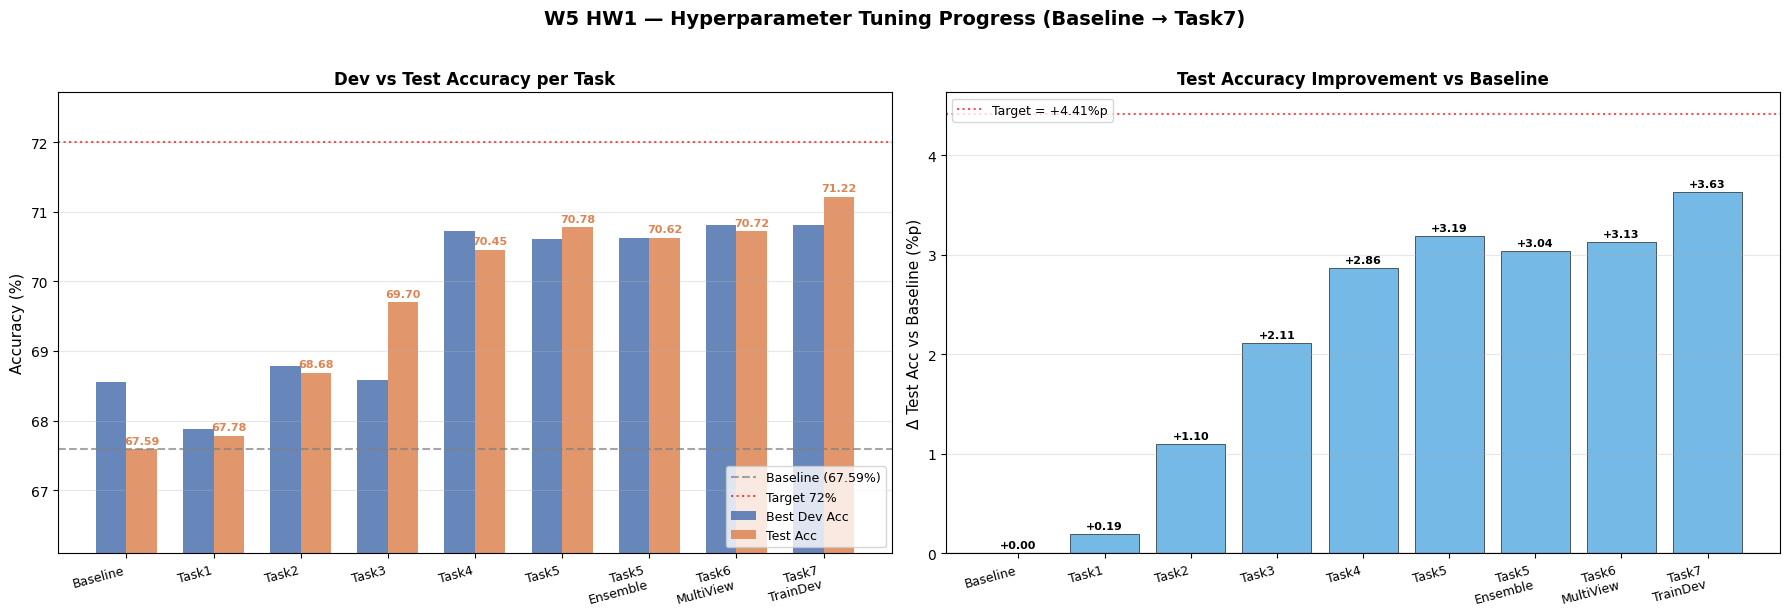

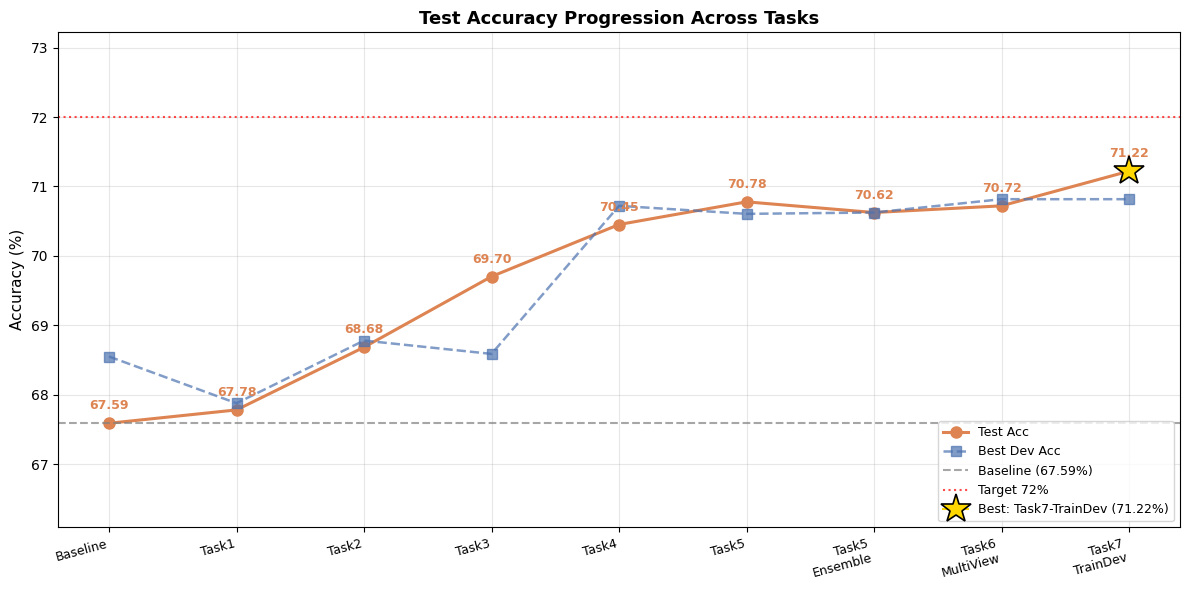

Summary (테이블 형태)
Task                      Dev Acc   Test Acc    vs Baseline
--------------------------------------------------------------------------------
Baseline                   68.55%     67.59%        +0.00%p
Task1                      67.88%     67.78%        +0.19%p
Task2                      68.78%     68.68%        +1.10%p
Task3                      68.59%     69.70%        +2.11%p
Task4                      70.72%     70.45%        +2.86%p
Task5                      70.61%     70.78%        +3.19%p
Task5-Ensemble             70.62%     70.62%        +3.04%p
Task6-MultiView            70.82%     70.72%        +3.13%p
Task7-TrainDev             70.82%     71.22%        +3.63%p ← BEST


In [24]:
# ============================================================================
# Visualization — Task1~Task7 결과 시각화
# experiment_results와 baseline_acc에서 값을 동적으로 읽어옴 (하드코딩 없음)
# ============================================================================
import matplotlib.pyplot as plt
import numpy as _viz_np

# 표시할 순서대로 정렬 (baseline → Task1 → Task2 → ... → Task7-TrainDev)
_viz_order = ['Task1', 'Task2', 'Task3', 'Task4', 'Task5',
              'Task5-Ensemble', 'Task6-MultiView', 'Task7-TrainDev']

# 데이터 수집 (실행된 task만 포함)
_viz_labels = ['Baseline']
_viz_dev = [float(globals().get('baseline_dev', 0.6855))]  # 베이스라인 dev (실행 로그상)
_viz_test = [baseline_acc]

for task_name in _viz_order:
    rec = next((r for r in experiment_results if r['task'] == task_name), None)
    if rec is not None:
        _viz_labels.append(task_name.replace('-', '\n'))
        _viz_dev.append(rec['best_dev_acc'])
        _viz_test.append(rec['test_acc'])

_viz_dev_pct = [v * 100 for v in _viz_dev]
_viz_test_pct = [v * 100 for v in _viz_test]
_viz_baseline_pct = baseline_acc * 100
_viz_target_pct = 72.0

# Figure 1: Dev vs Test 비교 막대그래프
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

x = _viz_np.arange(len(_viz_labels))
width = 0.35

bars_dev = ax1.bar(x - width/2, _viz_dev_pct, width, label='Best Dev Acc',
                    color='#4C72B0', alpha=0.85)
bars_test = ax1.bar(x + width/2, _viz_test_pct, width, label='Test Acc',
                     color='#DD8452', alpha=0.85)

ax1.axhline(y=_viz_baseline_pct, color='gray', linestyle='--', linewidth=1.5,
            label=f'Baseline ({_viz_baseline_pct:.2f}%)', alpha=0.7)
ax1.axhline(y=_viz_target_pct, color='red', linestyle=':', linewidth=1.5,
            label=f'Target 72%', alpha=0.7)

ax1.set_xticks(x)
ax1.set_xticklabels(_viz_labels, rotation=15, ha='right', fontsize=9)
ax1.set_ylabel('Accuracy (%)', fontsize=11)
ax1.set_title('Dev vs Test Accuracy per Task', fontsize=12, fontweight='bold')
ax1.legend(loc='lower right', fontsize=9)
ax1.set_ylim(min(min(_viz_dev_pct), min(_viz_test_pct)) - 1.5, max(max(_viz_dev_pct), max(_viz_test_pct)) + 1.5)
ax1.grid(axis='y', alpha=0.3)

# Test acc 위에 값 표시
for bar, v in zip(bars_test, _viz_test_pct):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.08,
             f'{v:.2f}', ha='center', fontsize=8, color='#DD8452', fontweight='bold')

# Figure 2: vs Baseline improvement (%p)
_viz_improvements = [v - _viz_baseline_pct for v in _viz_test_pct]
_viz_colors = ['#888888'] + ['#5DADE2' if imp >= 0 else '#E74C3C'
                              for imp in _viz_improvements[1:]]

bars_imp = ax2.bar(x, _viz_improvements, color=_viz_colors, alpha=0.85, edgecolor='black', linewidth=0.5)
ax2.axhline(y=0, color='black', linewidth=0.8)
ax2.axhline(y=(_viz_target_pct - _viz_baseline_pct), color='red', linestyle=':', linewidth=1.5,
            label=f'Target = +{_viz_target_pct - _viz_baseline_pct:.2f}%p', alpha=0.7)

ax2.set_xticks(x)
ax2.set_xticklabels(_viz_labels, rotation=15, ha='right', fontsize=9)
ax2.set_ylabel('Δ Test Acc vs Baseline (%p)', fontsize=11)
ax2.set_title('Test Accuracy Improvement vs Baseline', fontsize=12, fontweight='bold')
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(axis='y', alpha=0.3)

# Improvement 막대 위에 값 표시
for bar, v in zip(bars_imp, _viz_improvements):
    pos_y = bar.get_height() + (0.05 if v >= 0 else -0.18)
    ax2.text(bar.get_x() + bar.get_width() / 2, pos_y,
             f'{v:+.2f}', ha='center', fontsize=8, fontweight='bold')

plt.suptitle('W5 HW1 — Hyperparameter Tuning Progress (Baseline → Task7)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


# ============================================================================
# Figure 3: 누적 진행 line plot — task별 test acc 변화 + 72% 목표선
# ============================================================================
fig2, ax3 = plt.subplots(figsize=(12, 6))

ax3.plot(x, _viz_test_pct, marker='o', markersize=8, linewidth=2.2,
         color='#DD8452', label='Test Acc')
ax3.plot(x, _viz_dev_pct, marker='s', markersize=7, linewidth=1.8,
         color='#4C72B0', label='Best Dev Acc', alpha=0.7, linestyle='--')

ax3.axhline(y=_viz_baseline_pct, color='gray', linestyle='--', linewidth=1.5,
            label=f'Baseline ({_viz_baseline_pct:.2f}%)', alpha=0.7)
ax3.axhline(y=_viz_target_pct, color='red', linestyle=':', linewidth=1.5,
            label=f'Target 72%', alpha=0.7)

# 점 위에 acc 값 표시
for xi, yi in zip(x, _viz_test_pct):
    ax3.annotate(f'{yi:.2f}', xy=(xi, yi), xytext=(0, 10),
                 textcoords='offset points', ha='center',
                 fontsize=9, color='#DD8452', fontweight='bold')

# Best task 강조
_viz_best_idx = _viz_np.argmax(_viz_test_pct)
ax3.plot(_viz_best_idx, _viz_test_pct[_viz_best_idx], marker='*', markersize=22,
         color='gold', markeredgecolor='black', markeredgewidth=1.2,
         label=f'Best: {_viz_labels[_viz_best_idx].replace(chr(10), "-")} ({_viz_test_pct[_viz_best_idx]:.2f}%)',
         zorder=5)

ax3.set_xticks(x)
ax3.set_xticklabels(_viz_labels, rotation=15, ha='right', fontsize=9)
ax3.set_ylabel('Accuracy (%)', fontsize=11)
ax3.set_title('Test Accuracy Progression Across Tasks', fontsize=13, fontweight='bold')
ax3.legend(loc='lower right', fontsize=9)
ax3.set_ylim(min(_viz_test_pct) - 1.5, max(_viz_test_pct) + 2)
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# 텍스트 요약 출력
# ============================================================================
print("=" * 80)
print("Summary (테이블 형태)")
print("=" * 80)
print(f"{'Task':<22} {'Dev Acc':>10} {'Test Acc':>10} {'vs Baseline':>14}")
print("-" * 80)
for label, dv, ts in zip(_viz_labels, _viz_dev_pct, _viz_test_pct):
    lbl_clean = label.replace('\n', '-')
    delta = ts - _viz_baseline_pct
    marker = " ← BEST" if ts == max(_viz_test_pct) and lbl_clean != 'Baseline' else ""
    print(f"{lbl_clean:<22} {dv:>9.2f}% {ts:>9.2f}% {delta:>+12.2f}%p{marker}")
print("=" * 80)


## Output_Format

**과제 2: 모델(모형) 예측 부분 추가 구현.**

사용자가 입력한 문장에 대해 학습된 **Task7-TrainDev (Multi-View Ensemble + Train+Dev Retrain)** 모델이 sentiment를 예측하여 다음 형식으로 출력합니다.

```
Input sentence: <문장>
This sentence is <positive | negative | neutral> sentence.
```

아래 셀은 Task6의 14개 멤버 구성을 그대로 가져와 각 멤버를 **train+dev 합쳐서 재학습**(Task7 protocol)한 뒤, 각 멤버의 softmax 확률을 평균(uniform soft voting)하고 dev 기준 class-bias calibration을 적용합니다. `predict_sentiment(text)` 함수로 임의의 입력 문장에 대해 Task7 ensemble 예측 결과를 제공합니다.

In [25]:
# ============================================================================
# Output Format — Task7-TrainDev 기반 모델 예측 데모
# Task6 멤버 14개 구성을 그대로 가져와 train+dev 재학습 (Task7 protocol)
# 각 멤버 모델/vectorizer/selector를 메모리에 보존하여 predict_sentiment(text) 제공
# ============================================================================
import copy as _pred_copy
import gc as _pred_gc
import numpy as _pred_np
import torch as _pred_torch
import torch.optim as _pred_optim
from scipy import sparse as _pred_sparse
from sklearn.feature_extraction.text import TfidfVectorizer as _pred_TfidfVec
from sklearn.feature_selection import SelectKBest as _pred_SelectKBest, chi2 as _pred_chi2

# ----------------------------------------------------------------------------
# 0) 사전조건: Task6 결과가 메모리에 있어야 함 (best_epoch / dev probs 재사용)
# ----------------------------------------------------------------------------
if '_t6_all_summaries' not in globals() or '_t6_all_dev_probs' not in globals():
    raise RuntimeError(
        "Output Format 셀은 Task6 (cell 27) 먼저 실행되어 있어야 합니다. "
        "Task5-Ensemble (cell 25) → Task6 (cell 27) 순서로 실행해주세요."
    )

# ----------------------------------------------------------------------------
# 1) View별 train+dev features 빌드 (각 view 1회씩, 멤버들끼리 공유)
# ----------------------------------------------------------------------------
def _pred_build_traindev_artifacts(config):
    """config에 맞게 train+dev로 vectorizer + (optional) chi2 selector fit.
    Returns dict with 'kind', 'word_vec', 'char_vec', 'selector', 'x_traindev', 'y_traindev'.
    """
    kind = config['feature_kind']
    tr = maybe_normalize(train_texts, config)
    dv = maybe_normalize(dev_texts, config)
    all_texts = tr + dv
    all_labels = _pred_np.concatenate([train_labels_np, dev_labels_np])

    if kind == 'char_tfidf':
        char_vec = _pred_TfidfVec(
            lowercase=True, analyzer=config.get('analyzer', 'char'),
            ngram_range=config.get('ngram_range', (3, 6)),
            min_df=config.get('min_df', 2), max_df=config.get('max_df', 1.0),
            max_features=FIXED_INPUT_SIZE,
            sublinear_tf=config.get('sublinear_tf', True), norm='l2',
        )
        char_vec.fit(all_texts)
        x_traindev = ensure_fixed_dim(char_vec.transform(all_texts))
        return {'kind': kind, 'word_vec': None, 'char_vec': char_vec,
                'selector': None, 'x_traindev': x_traindev, 'y_traindev': all_labels}

    if kind == 'word_char_chi2':
        word_vec = _pred_TfidfVec(
            lowercase=True, analyzer='word',
            ngram_range=config.get('word_ngram', (1, 2)),
            min_df=config.get('word_min_df', 1), max_df=config.get('word_max_df', 1.0),
            max_features=config.get('word_pool', 120000),
            sublinear_tf=config.get('sublinear_tf', True),
            norm='l2', token_pattern=r'(?u)\b\w+\b',
        )
        char_vec = _pred_TfidfVec(
            lowercase=True, analyzer=config.get('char_analyzer', 'char_wb'),
            ngram_range=config.get('char_ngram', (3, 5)),
            min_df=config.get('char_min_df', 2), max_df=config.get('char_max_df', 1.0),
            max_features=config.get('char_pool', 120000),
            sublinear_tf=config.get('sublinear_tf', True), norm='l2',
        )
        word_vec.fit(all_texts)
        char_vec.fit(all_texts)
        joined = _pred_sparse.hstack(
            [word_vec.transform(all_texts), char_vec.transform(all_texts)], format='csr'
        )
        selector = _pred_SelectKBest(_pred_chi2, k=min(FIXED_INPUT_SIZE, joined.shape[1]))
        selector.fit(joined, all_labels)
        x_traindev = ensure_fixed_dim(selector.transform(joined))
        return {'kind': kind, 'word_vec': word_vec, 'char_vec': char_vec,
                'selector': selector, 'x_traindev': x_traindev, 'y_traindev': all_labels}

    raise ValueError(f"unsupported feature_kind: {kind}")


_pred_view_configs = {'Task3': task3_config, 'Task4': task4_config, 'Task5': task5_config}
_pred_unique_views = sorted({s['view'] for s in _t6_all_summaries})

print(f"[Setup] Task7 ensemble — {len(_t6_all_summaries)} members across views: {_pred_unique_views}")
print("[Setup] Building train+dev features per view...")
_pred_view_artifacts = {}
for _view in _pred_unique_views:
    _pred_view_artifacts[_view] = _pred_build_traindev_artifacts(_pred_view_configs[_view])
    _art = _pred_view_artifacts[_view]
    print(f"  - {_view}: kind={_art['kind']}, x_traindev shape={_art['x_traindev'].shape}")


# ----------------------------------------------------------------------------
# 2) 각 멤버 train+dev 재학습 (Task7 protocol). best_epoch는 Task6 결과 재사용.
# ----------------------------------------------------------------------------
def _pred_train_member(view, seed, fixed_epochs):
    config = _pred_view_configs[view]
    artifacts = _pred_view_artifacts[view]
    x_traindev = artifacts['x_traindev']
    y_traindev = artifacts['y_traindev']

    set_all_seeds(seed)
    model = MLP(FIXED_INPUT_SIZE, hidden_size, output_size).to(device)
    opt = _pred_optim.AdamW(
        model.parameters(), lr=config['lr'],
        weight_decay=config.get('weight_decay', 0.0),
    )
    sched = None
    if config.get('scheduler') == 'cosine':
        sched = _pred_optim.lr_scheduler.CosineAnnealingLR(
            opt, T_max=max(1, fixed_epochs),
            eta_min=config.get('eta_min', config['lr'] * 0.03),
        )

    n = x_traindev.shape[0]
    rng = _pred_np.random.default_rng(seed)
    for ep in range(1, fixed_epochs + 1):
        model.train()
        perm = rng.permutation(n)
        for start in range(0, n, config['batch_size']):
            idx = perm[start:start + config['batch_size']]
            xb = sparse_rows_to_tensor(x_traindev, idx)
            yb = _pred_torch.tensor(y_traindev[idx], dtype=_pred_torch.long, device=device)
            out = model(xb)
            lp = _pred_torch.log(out.clamp_min(1e-8))
            loss = smooth_nll_loss(lp, yb, label_smoothing=config.get('label_smoothing', 0.0))
            opt.zero_grad()
            loss.backward()
            if config.get('grad_clip') is not None:
                _pred_torch.nn.utils.clip_grad_norm_(model.parameters(), config['grad_clip'])
            opt.step()
        if sched is not None:
            sched.step()
    model.eval()
    del opt, sched
    return model


print(f"\n[Train] Retraining all {len(_t6_all_summaries)} members on train+dev (Task7 protocol)...")
_pred_members = []  # list of dicts {view, seed, model}
for i, summary in enumerate(_t6_all_summaries, 1):
    view = summary['view']
    seed = summary['seed']
    best_epoch = summary['best_epoch']
    print(f"  [{i:2d}/{len(_t6_all_summaries)}] {view} seed={seed:>5} → train+dev for {best_epoch} epochs", end=' ')
    model = _pred_train_member(view, seed, best_epoch)
    _pred_members.append({'view': view, 'seed': seed, 'model': model})
    print("✓")

# train+dev 텐서는 학습 후 더 이상 필요 없음 (메모리 정리)
for _v in _pred_view_artifacts:
    _pred_view_artifacts[_v]['x_traindev'] = None
    _pred_view_artifacts[_v]['y_traindev'] = None
_pred_gc.collect()
if _pred_torch.cuda.is_available():
    _pred_torch.cuda.empty_cache()

# ----------------------------------------------------------------------------
# 3) Class-bias calibration: Task6의 phase 1 dev probs 평균 → tune_class_bias
# ----------------------------------------------------------------------------
_pred_dev_probs_mean = _pred_np.mean(_t6_all_dev_probs, axis=0)
_pred_bias, _pred_calib_dev_acc = tune_class_bias(_pred_dev_probs_mean, dev_labels_np)
print(f"\n[Calibration] dev class_bias = {_pred_np.round(_pred_bias, 3).tolist()}")
print(f"              calibrated dev acc = {_pred_calib_dev_acc*100:.2f}%")


# ----------------------------------------------------------------------------
# 4) 입력 텍스트 → 각 view의 sparse vector로 transform
# ----------------------------------------------------------------------------
def _pred_transform_text(text, view):
    artifacts = _pred_view_artifacts[view]
    config = _pred_view_configs[view]
    normalized = maybe_normalize([text], config)
    if artifacts['kind'] == 'char_tfidf':
        x_sparse = ensure_fixed_dim(artifacts['char_vec'].transform(normalized))
    else:  # word_char_chi2
        joined = _pred_sparse.hstack(
            [artifacts['word_vec'].transform(normalized),
             artifacts['char_vec'].transform(normalized)],
            format='csr',
        )
        x_sparse = ensure_fixed_dim(artifacts['selector'].transform(joined))
    return _pred_torch.tensor(x_sparse.toarray(), dtype=_pred_torch.float32, device=device)


# ----------------------------------------------------------------------------
# 5) Label → sentiment mapping (Sp1786 dataset 기준)
# ----------------------------------------------------------------------------
LABEL_TO_SENTIMENT = {0: 'negative', 1: 'neutral', 2: 'positive'}


def predict_sentiment(text):
    """입력 문장에 대해 Task7 ensemble (14 members soft voting + calibration) 예측.

    Returns:
        sentiment (str): 'positive' | 'negative' | 'neutral'
        confidence (float): ensemble argmax 클래스의 평균 softmax 확률
        probs (np.ndarray): [neg, neu, pos] 평균 softmax 확률
    """
    # View별 한 번씩만 transform (같은 view 멤버들끼리 공유)
    view_tensors = {v: _pred_transform_text(text, v) for v in _pred_unique_views}

    probs_per_member = []
    with _pred_torch.no_grad():
        for m in _pred_members:
            x = view_tensors[m['view']]
            p = m['model'](x).cpu().numpy()[0]
            probs_per_member.append(p)

    mean_probs = _pred_np.mean(probs_per_member, axis=0)  # uniform soft voting
    calibrated = _pred_np.log(_pred_np.clip(mean_probs, 1e-8, 1.0)) + _pred_bias
    label = int(_pred_np.argmax(calibrated))
    sentiment = LABEL_TO_SENTIMENT[label]
    confidence = float(mean_probs[label])
    return sentiment, confidence, mean_probs


# ----------------------------------------------------------------------------
# 6) 예시 문장 예측 — 과제 출력 형식에 맞춰서
# ----------------------------------------------------------------------------
EXAMPLE_SENTENCES = [
    "I love this item, it works perfectly and arrived quickly!",
    "This product is absolutely terrible and a complete waste of money.",
    "The shipment arrived on time, contents matched the description.",
    "Best purchase ever!! highly recommended for anyone.",
    "Disappointed, the quality is much worse than expected.",
    "It's an okay product, nothing special but does the job.",
    "I really enjoyed the experience, will definitely use it again.",
]

print("\n" + "=" * 72)
print(f"모델 예측 결과 (Task7 ensemble: {len(_pred_members)} members, calibrated)")
print("=" * 72)
for _sent in EXAMPLE_SENTENCES:
    _s, _conf, _probs = predict_sentiment(_sent)
    print(f"\nInput sentence: {_sent}")
    print(f"This sentence is {_s} sentence.")
    print(f"   (confidence={_conf*100:.1f}% | "
          f"neg={_probs[0]*100:.1f}% / neu={_probs[1]*100:.1f}% / pos={_probs[2]*100:.1f}%)")
print()

# ----------------------------------------------------------------------------
# 7) 새 문장 직접 테스트
# ----------------------------------------------------------------------------
print("=" * 72)
print("새 문장 직접 테스트: my_input 변수를 수정한 뒤 셀을 다시 실행하거나,")
print('   predict_sentiment("your sentence here")를 호출하세요.')
print("=" * 72)

my_input = "Type your sentence here to test the Task7 ensemble model"
_my_s, _my_conf, _my_probs = predict_sentiment(my_input)
print(f"\nInput sentence: {my_input}")
print(f"This sentence is {_my_s} sentence.")
print(f"   (confidence={_my_conf*100:.1f}% | "
      f"neg={_my_probs[0]*100:.1f}% / neu={_my_probs[1]*100:.1f}% / pos={_my_probs[2]*100:.1f}%)")


[Setup] Task7 ensemble — 14 members across views: ['Task3', 'Task4', 'Task5']
[Setup] Building train+dev features per view...
  - Task3: kind=char_tfidf, x_traindev shape=(36437, 29053)
  - Task4: kind=word_char_chi2, x_traindev shape=(36437, 29053)
  - Task5: kind=word_char_chi2, x_traindev shape=(36437, 29053)

[Train] Retraining all 14 members on train+dev (Task7 protocol)...
  [ 1/14] Task5 seed=    7 → train+dev for 5 epochs ✓
  [ 2/14] Task5 seed=   42 → train+dev for 6 epochs ✓
  [ 3/14] Task5 seed=    0 → train+dev for 5 epochs ✓
  [ 4/14] Task5 seed= 2024 → train+dev for 6 epochs ✓
  [ 5/14] Task5 seed=  123 → train+dev for 5 epochs ✓
  [ 6/14] Task5 seed=   11 → train+dev for 5 epochs ✓
  [ 7/14] Task5 seed=   33 → train+dev for 5 epochs ✓
  [ 8/14] Task5 seed=   99 → train+dev for 5 epochs ✓
  [ 9/14] Task5 seed=  777 → train+dev for 5 epochs ✓
  [10/14] Task5 seed= 1234 → train+dev for 5 epochs ✓
  [11/14] Task3 seed=   99 → train+dev for 4 epochs ✓
  [12/14] Task3 seed=   